# F_ephys_behavior_action&outcome.ipynb

## Purpose
The primary neural coding notebook. Analyzes how single units encode behavioral variables related to actions and outcomes during the task. This notebook performs GLM-based analysis to identify neurons tuned to specific task variables including outcome, chosen action (Q-value), and policy updates.

## Manuscript figure panels
This notebook generates figure panels showing:
- Neural activity aligned to task events (go cue, outcome)
- ROC/AUC analysis for outcome-selective neurons
- Spatial distribution of functionally-defined neurons in PrL and S1
- Tuning curves for outcome and Q-value encoding
- Comparison with photometry data
- Policy update encoding in neural populations

## Prerequisites
- Combined session data with quality control applied
- Waveform features extracted
- Basic ephys metrics computed
- GLM model results for behavioral variable encoding

In [1]:
import sys
import os
from matplotlib.colors import LinearSegmentedColormap
# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import sys
import os
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
from pathlib import Path
from matplotlib.colors import Normalize
import pycircstat2 as circ
import glob
import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb
from utils.ephys_functions import*
from utils.ccf_utils import ccf_pts_convert_to_mm, pir_to_lps, project_to_plane
from utils.combine_tools import apply_qc, to_str_intlike, spatial_dependence_summary, binary_shift_P_vs_U, welch_shift_P_vs_U, binary_shift_X_vs_Y, welch_shift_X_vs_Y
from utils.plot_utils import combine_pdf_big
from utils.capsule_migration import capsule_directories
import pickle
import scipy.stats as stats
import spikeinterface as si
import shutil
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score
import warnings
from scipy.stats import gaussian_kde
import trimesh
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from utils.ccf_utils import ccf_pts_convert_to_mm
from trimesh import load_mesh
from scipy.stats import pearsonr
import statsmodels.api as sm
from aind_ephys_utils import align
import k3d
from scipy.stats import rankdata
from scipy.ndimage import binary_dilation
from skimage.measure import find_contours
from joblib import Parallel, delayed
warnings.filterwarnings('ignore')
capsule_dirs = capsule_directories()

%matplotlib inline
from utils.capsule_migration import CAPSULE_ROOT
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df


## Setup and Configuration

Configure output directories and analysis parameters. This section sets up the target folder for saving figures and defines the criteria for selecting units and sessions to analyze.

# Load data

In [2]:
target_folder = os.path.join(capsule_dirs["manuscript_fig_dir"], 'F_ephys_beh_action&outcome')
if not os.path.exists(target_folder):
    os.makedirs(target_folder)
mesh_file = os.path.join(capsule_dirs["data_dir"], 'LC_percentile_meshes', 'core_mesh.obj')
# mesh_file_old = os.path.join(str(capsule_directories()['derived_dir']), 'combined', 'ccf_maps', '20250418_transformed_remesh_10_ccf25.obj')

In [3]:
criteria_name = 'beh_all'
beh_criteria = 'beh_only'
version = 'PrL_S1'

In [4]:
# # load waveforms
# waveform_criteria = 'waveform_all'
# waveform_type = '_raw'
# wf_folder  = os.path.join(str(capsule_directories()['derived_dir']) + '/combined/wf_plots', waveform_criteria, waveform_type)
# wf_feature_file = os.path.join(wf_folder, 'wf_features_combined.pkl')
# with open(wf_feature_file, 'rb') as f:
#     wf_features = pickle.load(f)
# wf_features.rename(columns={'unit': 'unit_id'}, inplace=True)
# wf_features['unit_id'] = wf_features['unit_id'].apply(to_str_intlike)
# wf_features.drop(columns=['probe'], inplace=True)

## Data Loading: Waveform Features

Load waveform features for all units. These features include spike width, peak-to-trough ratio, and repolarization time, which help distinguish between putative cell types (narrow-spiking vs. broad-spiking neurons).

In [5]:
# load waveforms
waveform_criteria = 'waveform_all'
waveform_type = '_raw'
wf_folder  = os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'waveforms_np')
wf_feature_file = os.path.join(wf_folder, 'combined_features.csv')
wf_features = pd.read_csv(wf_feature_file)
# 
wf_features.rename(columns={'unit': 'unit_id'}, inplace=True)
wf_features['unit_id'] = wf_features['unit_id'].apply(to_str_intlike)
wf_features.drop(columns=['probe'], inplace=True)

In [6]:
# load basic ephys
be_criteria = 'basic_ephys'
be_folder = os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'basic_ephys')
be_file = os.path.join(be_folder, 'basic_ephys.pkl')
with open(be_file, 'rb') as f:
    basic_ephys_df = pickle.load(f)
filter = basic_ephys_df['be_filter'].values
filter = np.array(filter, dtype=bool)
basic_ephys_df['be_filter'] = filter
basic_ephys_df.rename(columns={'unit': 'unit_id'}, inplace=True)
basic_ephys_df['unit_id'] = basic_ephys_df['unit_id'].apply(to_str_intlike)

## Data Loading: Basic Ephys Metrics

Load basic electrophysiology metrics including firing rates, ISI violations, and presence ratios. These metrics are used for quality control and characterizing unit properties.

In [7]:
# load basic constraints and data (unit + behavior)
with open(os.path.join(capsule_dirs['manuscript_fig_prep_dir'], 'combined_unit_tbl', 'combined_unit_tbl.pkl'), 'rb') as f:
    combined_tagged_units = pickle.load(f)
combined_tagged_units.rename(columns={'unit': 'unit_id'}, inplace=True)
combined_tagged_units['unit_id'] = combined_tagged_units['unit_id'].apply(to_str_intlike)
# merge with behavior 
with open(os.path.join(capsule_dirs['manuscript_fig_prep_dir'], 'combined_session_tbl', 'combined_beh_sessions.pkl'), 'rb') as f:
    combined_session_qc = pickle.load(f)
combined_session_qc.drop(columns=['probe'], inplace=True, errors='ignore')
combined_session_qc.loc[combined_session_qc['p_st_w']==1, 'diff_1'] = 5
# combined_tagged_units = combined_tagged_units.merge(combined_session_qc, on='session', how='left')

# antidromic data
antidromic_file = f'{capsule_dirs["manuscript_fig_prep_dir"]}/antidromic_analysis/{version}/combined_antidromic_results.pkl'
with open(antidromic_file, 'rb') as f:
    antidromic_df = pickle.load(f)

antidromic_df.rename(columns={'unit': 'unit_id'}, inplace=True)
antidromic_df['unit_id'] = antidromic_df['unit_id'].apply(to_str_intlike)
antidromic_df = antidromic_df[['unit_id', 'session', 'p_auto_inhi', 't_auto_inhi',
       'p_collision', 't_collision', 'p_antidromic', 't_antidromic', 'tier_1',
       'tier_2', 'tier_1_long', 'tier_2_long']].copy()
combined_tagged_units = combined_tagged_units.merge(antidromic_df, on=['session', 'unit_id'], how='left')
combined_tagged_units['tier_1'].fillna(False, inplace=True)
combined_tagged_units['tier_2'].fillna(False, inplace=True)
combined_tagged_units['tier_1_long'].fillna(False, inplace=True)
combined_tagged_units['tier_2_long'].fillna(False, inplace=True)

with open(os.path.join(CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics', f'{criteria_name}.json'), 'r') as f:
    constraints = json.load(f)
with open(os.path.join(CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics', f'{beh_criteria}.json'), 'r') as f:
    beh_constraints = json.load(f)
# start with a mask of all True
mask = pd.Series(True, index=combined_tagged_units.index)

Applying conditional bounds for isi_violations
 - isi_violations: 15278 -> 6737 units passed
Applying items for qc_pass: [True]
 - qc_pass: 6737 -> 4497 units passed
Applying bounds for peak: [-1000, 500]
 - peak: 4497 -> 4474 units passed
Applying items for in_df: [True]
 - in_df: 4474 -> 4239 units passed
Applying conditional bounds for y_loc
 - y_loc: 4239 -> 2975 units passed
Applying bounds for trial_count: [100, 2000]
 - trial_count: 2975 -> 2961 units passed
Applying bounds for sd: [0, 0.3]
 - sd: 2961 -> 1365 units passed
Applying opto conditions: ['p_max', 'eu', 'corr', 'tag_loc', 'lat_max_p', 'p_mean', 'sig_counts']
Number of opto rows after filtering: 297
Number of non-opto rows after filtering: 1365


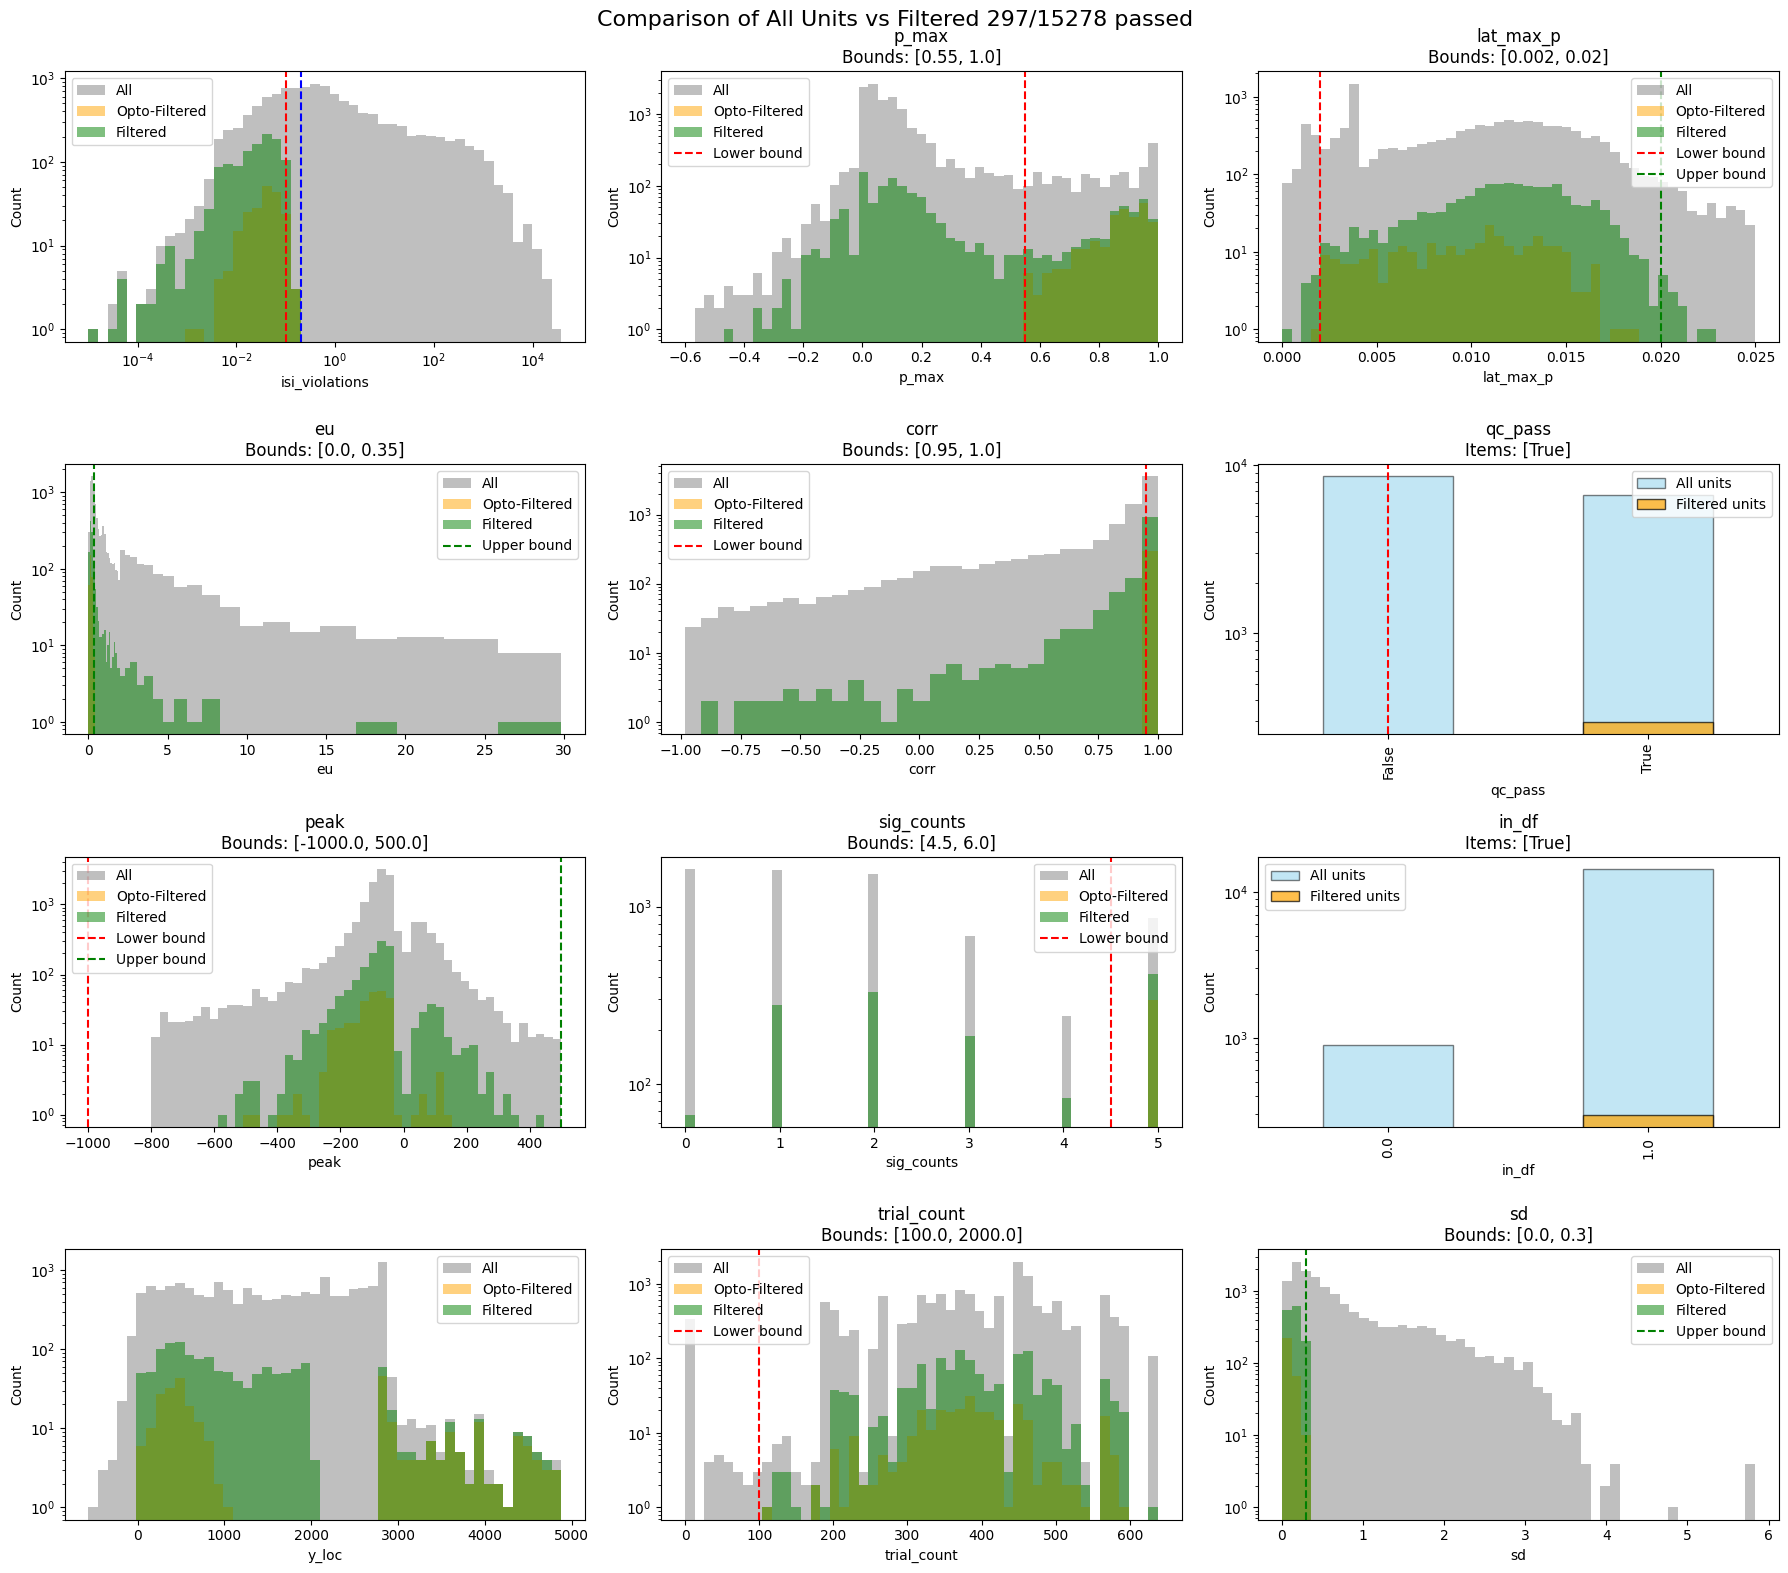

In [8]:
density = False
combined_tagged_units_filtered, combined_tagged_units, fig, axes = apply_qc(combined_tagged_units, constraints, density=density)
combined_tagged_units.rename(columns={'unit': 'unit_id'}, inplace=True)
combined_tagged_units['unit_id'] = combined_tagged_units['unit_id'].apply(to_str_intlike)
combined_tagged_units_filtered.rename(columns={'unit': 'unit_id'}, inplace=True)
combined_tagged_units_filtered['unit_id'] = combined_tagged_units_filtered['unit_id'].apply(to_str_intlike)
fig.savefig(fname=os.path.join(target_folder, f'unit_quality_metrics_summary_density_{density}.pdf'))

Applying bounds for session_len: [90, None]
 - session_len: 345 -> 344 units passed
Applying bounds for p_sw_L: [0.04, None]
 - p_sw_L: 344 -> 341 units passed
Applying bounds for aN: [0.15, None]
 - aN: 341 -> 278 units passed
Applying bounds for diff_1: [0, None]
 - diff_1: 278 -> 277 units passed
Applying bounds for bias: [-1.25, 1.25]
 - bias: 277 -> 259 units passed
Number of opto rows after filtering: 259
Number of non-opto rows after filtering: 259


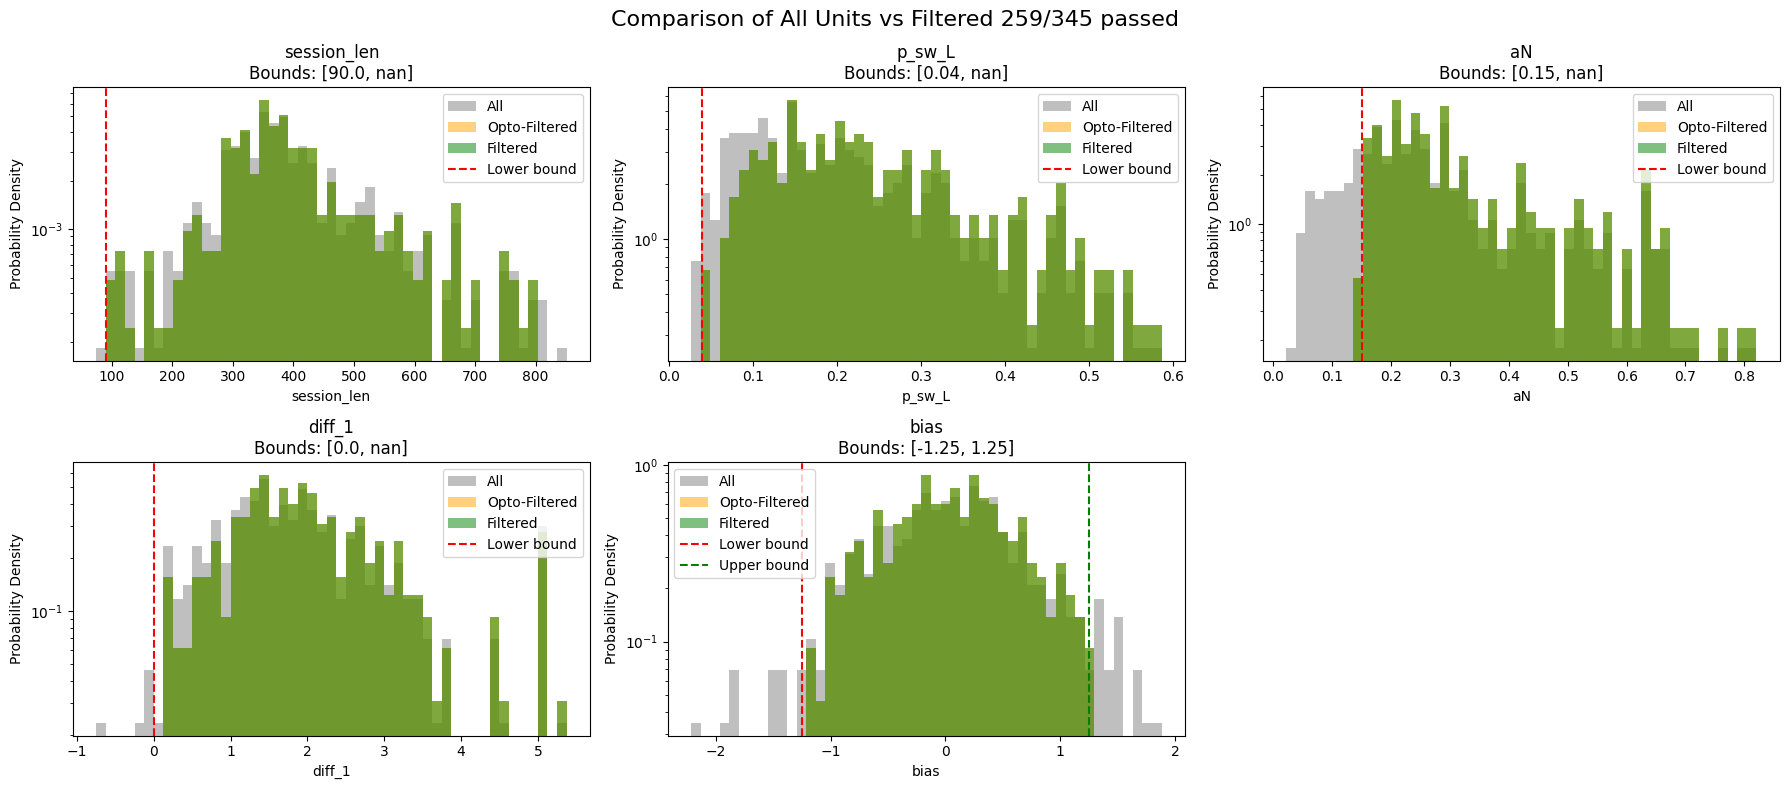

In [9]:
combined_filtered_beh, combined_labeled_beh, fig, axes = apply_qc(combined_session_qc, beh_constraints)

In [10]:
# combined_tagged_units_beh.rename(columns={'unit': 'unit_id'}, inplace=True)
# combined_tagged_units_beh['unit_id'] = combined_tagged_units_beh['unit_id'].apply(to_str_intlike)

In [11]:
# load and add model variables
model_combined = pd.read_csv(
    os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'outcome_regressions', f'model_combined_{criteria_name}.csv'),
    index_col=0,
)
model_combined['theta'] = model_combined['theta'] - 0.5
model_combined['unit_id'] = model_combined['unit_id'].apply(to_str_intlike)

versions = ['e', 'l', 'com']
for version in versions:
    all_vec = np.column_stack((
        model_combined[f'coef_outcome_{version}_mc'],
        model_combined[f'coef_Qchosen_{version}_ori']
    ))
    theta, rho = np.arctan2(all_vec[:, 1], all_vec[:, 0]), np.hypot(all_vec[:, 1], all_vec[:, 0])
    bound_1, bound_2, bound_3 = -(1 / 4) * np.pi, np.pi, -np.pi
    theta_scaled_dis = np.zeros_like(theta)
    for ind, angle_curr in enumerate(theta):
        if bound_1 < angle_curr <= bound_2:
            theta_scaled_dis[ind] = (angle_curr - bound_1) / (bound_2 - bound_1)
        else:
            theta_scaled_dis[ind] = (bound_1 - angle_curr) / (bound_1 - bound_3)
    theta_scaled_dis_all = 1 - theta_scaled_dis - 0.5
    model_combined[f'theta_{version}'] = theta_scaled_dis_all

# derived features
model_combined['coef_outcome|(|coef_outcome| + |coef_Q|)'] = (
    model_combined['coef_outcome_com_mc'] /
    (np.abs(model_combined['coef_outcome_com_mc']) + np.abs(model_combined['coef_Qchosen_com_mc']))
)
model_combined['outcome_ipsi'] = (
    model_combined['coef_outcome_com_mc'] + model_combined['coef_outcome:ipsi_com_mc']
)
model_combined['outcome_contra'] = (
    model_combined['coef_outcome_com_mc'] - model_combined['coef_outcome:ipsi_com_mc']
)
# combined-beh
model_combined = model_combined.merge(combined_labeled_beh[['session', 'selected', 'diff_1']], on=['session'], how='left')
# model_combined = model_combined[model_combined['selected']]`

In [12]:
# Combine all features
features_combined = pd.merge(model_combined, wf_features, on=['session', 'unit_id'], suffixes=('', '_wf'), how='outer')
features_combined = pd.merge(features_combined, basic_ephys_df, on=['session', 'unit_id'], suffixes=('', '_be'), how='outer')
response_tbl = pd.read_csv(
    os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'response_regression', f'response_ratio_{criteria_name}_go_cue.csv')
)
response_tbl['unit_id'] = response_tbl['unit'].apply(to_str_intlike)
features_combined = features_combined.merge(response_tbl, on=['session', 'unit_id'], how='outer')

# features_combined = features_combined.merge(antidromic_df, on=['session', 'unit_id'], how='outer')
features_combined = features_combined.merge(combined_tagged_units[['session', 'unit_id', 'probe', 'sex', 'x_ccf', 'y_ccf', 'z_ccf', 'tier_1', 'tier_2', 'isi_violations', 'sd']], on=['session', 'unit_id'], how='right')
features_combined['be_filter'].fillna(False, inplace=True)
features_combined['selected'].fillna(False, inplace=True)
# filter with combined_tagged_units_filtered
# keep if session, unit in combined_tagged_units_filtered
mask_filtered = features_combined.set_index(['session', 'unit_id']).index.isin(
    combined_tagged_units_filtered.set_index(['session', 'unit_id']).index
)
features_combined = features_combined[mask_filtered].copy()

## Data Loading: GLM Model Results

Load the GLM (Generalized Linear Model) results that quantify how well each unit encodes various behavioral variables. The model includes terms for outcome, chosen Q-value, unchosen Q-value, choice, lick direction, and policy updates. Statistical significance is assessed using permutation tests.

In [13]:
# save
output_file = os.path.join(target_folder, f'features_combined_{criteria_name}.pkl')
with open(output_file, 'wb') as f:
    pickle.dump(features_combined, f)

In [14]:
aniNames = [parseSessionID(session_curr)[0] for session_curr in combined_tagged_units['session']]
aniNames_F = [parseSessionID(session_curr)[0] for session_curr in combined_tagged_units[(combined_tagged_units['sex']=='F')]['session']]
print(f"Animals count: {len(set(aniNames))}")
print(f"Animals count (F): {len(set(aniNames_F))}")
print(f"Session count: {len(combined_tagged_units['session'].unique())}")

Animals count: 23
Animals count (F): 4
Session count: 167


In [15]:
mask = features_combined['selected'].values
aniNames = [parseSessionID(session_curr)[0] for session_curr in features_combined[mask]['session']]
aniNames_F = [parseSessionID(session_curr)[0] for session_curr in features_combined[mask & (features_combined['sex']=='F')]['session']]
print(f"Total units passed: {len(features_combined)}")
print(f"Animals count: {len(set(aniNames))}")
print(f"Animals count (F): {len(set(aniNames_F))}")
print(f"Session count: {len(features_combined[mask]['session'].unique())}")
print(f"Unit count: {len(features_combined[mask])}")

Total units passed: 297
Animals count: 19
Animals count (F): 3
Session count: 106
Unit count: 241


In [16]:
mask = features_combined['selected'].values & (features_combined['x_ccf'].notna()) & (features_combined['y_ccf'].notna()) & (features_combined['z_ccf'].notna())
aniNames = [parseSessionID(session_curr)[0] for session_curr in features_combined[mask]['session']]
aniNames_F = [parseSessionID(session_curr)[0] for session_curr in features_combined[mask & (features_combined['sex']=='F')]['session']]
print('With CCF coordinates:')
print(f"Animals count: {len(set(aniNames))}")
print(f"Animals count (F): {len(set(aniNames_F))}")
print(f"Session count: {len(features_combined[mask]['session'].unique())}")
print(f"Unit count: {len(features_combined[mask])}")

With CCF coordinates:
Animals count: 15
Animals count (F): 3
Session count: 33
Unit count: 115


# Gather all single neuron analysis

In [17]:
# put all behavior into 1 folder
gather_single_unts = False
filter = features_combined['selected'].values
if gather_single_unts:
    target_folder = target_folder
    all_pdf_dir = os.path.join(target_folder, 'all_pdfs')
    beh_response_pdf_folder = os.path.join(all_pdf_dir, 'response')
    beh_go_cue_pdf_folder = os.path.join(all_pdf_dir, 'go_cue')
    opto_pdf_folder = os.path.join(all_pdf_dir, 'opto')
    drift_pdf_folder = os.path.join(all_pdf_dir, 'drift')
    burst_pdf_folder = os.path.join(all_pdf_dir, 'burst')
    # remove all current ones:
    shutil.rmtree(all_pdf_dir, ignore_errors=True)
    # make folders
    os.makedirs(beh_response_pdf_folder, exist_ok=True)
    os.makedirs(beh_go_cue_pdf_folder, exist_ok=True)
    os.makedirs(opto_pdf_folder, exist_ok=True)
    os.makedirs(drift_pdf_folder, exist_ok=True)
    os.makedirs(burst_pdf_folder, exist_ok=True)

    for ind, row in features_combined[filter].iterrows():
        session = row['session']
        unit_id = row['unit_id']
        unit_str = f'{unit_id}'
        session_dir = session_dirs(session)
        # opto
        opto_pdfs= os.listdir(session_dir['opto_dir_fig_curated'])
        opto_pdf = [opto_pdf for opto_pdf in opto_pdfs if opto_pdf.startswith(f'unit_{unit_str}_' ) and opto_pdf.endswith('opto_tagging.pdf')]
        if len(opto_pdf) == 0:
            opto_pdf = [opto_pdf for opto_pdf in opto_pdfs if opto_pdf.startswith(f'unit_{unit_str}.0_' ) and opto_pdf.endswith('opto_tagging.pdf')]
        if len(opto_pdf) > 0:
            opto_pdf = os.path.join(session_dir['opto_dir_fig_curated'], opto_pdf[0])
            # copy
            shutil.copy(opto_pdf, os.path.join(opto_pdf_folder, f'{session}_unit_{unit_str}_opto.pdf'))
        else:
            print(f'No opto pdf for session {session}, unit {unit_str}') 

        # drift
        if not os.path.exists(os.path.join(session_dir['opto_dir_curated'], 'drift')):
            print(f'No drift folder for session {session}, unit {unit_str}')
        else:
            drift_pdfs= os.listdir(os.path.join(session_dir['opto_dir_curated'], 'drift'))
            drift_pdf = [drift_pdf for drift_pdf in drift_pdfs if drift_pdf.startswith(f'{unit_str}_' ) and drift_pdf.endswith('drift.pdf')]
            if len(drift_pdf) == 0:
                drift_pdf = [drift_pdf for drift_pdf in drift_pdfs if drift_pdf.startswith(f'{unit_str}.0_' ) and drift_pdf.endswith('drift.pdf')]
            if len(drift_pdf) > 0:
                drift_pdf = os.path.join(session_dir['opto_dir_curated'], 'drift', drift_pdf[0])
                # copy
                shutil.copy(drift_pdf, os.path.join(drift_pdf_folder, f'{session}_{os.path.basename(drift_pdf)}'))
            else:
                print(f'No drift pdf for session {session}, unit {unit_str}')

        # go cue
        if not os.path.exists(os.path.join(session_dir['ephys_fig_dir_curated'], 'go_cue')):
            print(f'No go cue folder for session {session}, unit {unit_str}')
        else:
            beh_go_cue_pdfs= os.listdir(os.path.join(session_dir['ephys_fig_dir_curated'], 'go_cue'))
            beh_go_cue_pdf = [pdf for pdf in beh_go_cue_pdfs if pdf.startswith(f'unit_{unit_str}_' ) and pdf.endswith('.pdf')]
            if len(beh_go_cue_pdf) == 0:
                beh_go_cue_pdf = [pdf for pdf in beh_go_cue_pdfs if pdf.startswith(f'unit_{unit_str}.0_' ) and pdf.endswith('.pdf')]
            if len(beh_go_cue_pdf) > 0:
                beh_go_cue_pdf = os.path.join(session_dir['ephys_fig_dir_curated'], 'go_cue', beh_go_cue_pdf[0])
                # copy
                shutil.copy(beh_go_cue_pdf, os.path.join(beh_go_cue_pdf_folder, f'{session}_{os.path.basename(beh_go_cue_pdf)}'))
            else:
                print(f'No go cue pdf for session {session}, unit {unit_str}')
        # response
        if not os.path.exists(os.path.join(session_dir['ephys_fig_dir_curated'], 'response')):
            print(f'No response folder for session {session}, unit {unit_str}')
        else:
            beh_response_pdfs= os.listdir(os.path.join(session_dir['ephys_fig_dir_curated'], 'response'))
            beh_response_pdf = [pdf for pdf in beh_response_pdfs if pdf.startswith(f'unit_{unit_str}_' ) and pdf.endswith('.pdf')]
            if len(beh_response_pdf) == 0:
                beh_response_pdf = [pdf for pdf in beh_response_pdfs if pdf.startswith(f'unit_{unit_str}.0_' ) and pdf.endswith('.pdf')]
            if len(beh_response_pdf) > 0:
                beh_response_pdf = os.path.join(session_dir['ephys_fig_dir_curated'], 'response', beh_response_pdf[0])
                # copy use original filename to avoid overwriting
                shutil.copy(beh_response_pdf, os.path.join(beh_response_pdf_folder, f'{session}_{os.path.basename(beh_response_pdf)}'))
                print(f'Copied response pdf for session {session}, unit {unit_str}')
            else:
                print(f'No response pdf for session {session}, unit {unit_str}')
        # burst
        burst_file = os.path.join(os.path.join(session_dir['ephys_fig_dir_curated'], 'burst'), f'{session}_{unit_str}_burst_selected.pdf')
        target_burst_file = os.path.join(burst_pdf_folder, f'{session}_{unit_str}_burst.pdf')
        if os.path.exists(burst_file):
            shutil.copy(burst_file, target_burst_file)
            print(f'Copied burst pdf for session {session}, unit {unit_str}')
        else:
            print(f'No burst pdf for session {session}, unit {unit_str}')


In [18]:
combine = False
if combine:
    # combine all pdfs into 1 per category
    combine_pdf_big(beh_response_pdf_folder, os.path.join(all_pdf_dir, f'combined_response.pdf'))
    combine_pdf_big(beh_go_cue_pdf_folder, os.path.join(all_pdf_dir, f'combined_go_cue.pdf'))
    combine_pdf_big(opto_pdf_folder, os.path.join(all_pdf_dir, f'combined_opto.pdf'))
    combine_pdf_big(drift_pdf_folder, os.path.join(all_pdf_dir, f'combined_drift.pdf'))
    combine_pdf_big(burst_pdf_folder, os.path.join(all_pdf_dir, f'combined_burst.pdf'))


# Psth of all units. firing rate in baseline widnow, go cue window

In [19]:
# colormaps
reward_colors = LinearSegmentedColormap.from_list('outcome', [(0.0, 'magenta'), (0.5, 'white'), (1.0, 'cyan')])
hit_colors = LinearSegmentedColormap.from_list('hit', [(0.0, 'blue'), (0.5, 'white'), (1.0, 'orange')])
switch_colors = LinearSegmentedColormap.from_list('switch', [(0.0, 'green'), (0.5, 'white'), (1.0, 'purple')])
feature_map = {
'T_baseline_svs_hit': switch_colors,
'T_response_svs_hit': switch_colors,
'T_outcome_com_mc': reward_colors,
'T_outcome_l_mc': reward_colors, 
'T_baseline_hit_all': hit_colors, 
'T_response_hit_all': hit_colors
}

In [ ]:
def plot_psth_and_cat_firing_rate(features_combined, cat_col, align_time, bl_win, resp_win, target_folder, panels=None):

    def _process_one_unit(row, *, cat_col, align_time, bl_win, resp_win):
        """
        Returns:
          (psth_mean, mean_1_bl, mean_1_resp, mean_0_bl, mean_0_resp, time)
        or None to skip.
        """
        session = row["session"]
        unit_id = row["unit_id"]
        if "ZS" not in session:
            unit_id = int(unit_id)
        print(f"Processing session {session}, unit {unit_id}...")
        session_df = get_session_tbl(session)

        # switch vs stay
        session_df["svs"] = np.nan
        choices = session_df["animal_response"].values
        choice_inds = np.where(choices != 2)[0]
        choice_resp = choices[choice_inds]
        svs = (choice_resp[1:] != choice_resp[:-1]).astype(int)
        svs = np.insert(svs, 0, False)
        session_df.loc[choice_inds, "svs"] = svs

        # response vs no response
        session_df["hit"] = (session_df["animal_response"] != 2).astype(int)
        session_df["hit_clean"] = session_df["hit"]
        session_df.loc[session_df["rewarded_historyL"] | session_df["rewarded_historyR"] , "hit_clean"] = np.nan

        unit_tbl = get_unit_tbl(session, data_type="curated")
        unit_drift = load_drift(session, unit_id)
        spike_times = unit_tbl.query("unit_id == @unit_id")["spike_times"].values[0]

        session_df_curr = session_df.copy()
        spike_times_curr = spike_times.copy()

        if unit_drift is not None:
            if unit_drift["ephys_cut"][0] is not None:
                t0 = unit_drift["ephys_cut"][0]
                spike_times_curr = spike_times_curr[spike_times_curr >= t0]
                session_df_curr = session_df_curr[session_df_curr["goCue_start_time"] >= t0]
            if unit_drift["ephys_cut"][1] is not None:
                t1 = unit_drift["ephys_cut"][1]
                spike_times_curr = spike_times_curr[spike_times_curr <= t1]
                session_df_curr = session_df_curr[session_df_curr["goCue_start_time"] <= t1]

        if len(spike_times_curr) == 0 or len(session_df_curr) <= 5:
            return None

        psth, time = get_spike_matrix(
            spike_times_curr,
            session_df_curr[align_time].values,
            pre_event=-2,
            post_event=3,
            stepSize=0.05,
            avoid_overlap=True,
            kernel=True,
            tau_rise=0.001,
            tau_decay=0.08,
        )
        psth_mean = np.nanmean(psth, axis=0)

        baseline_rate = np.full(psth.shape[0], np.nan)
        response_rate = np.full(psth.shape[0], np.nan)

        align_times = session_df_curr[align_time].values
        for trial_ind in range(len(session_df_curr)):
            t_align = align_times[trial_ind]
            baseline_mask = (spike_times_curr >= bl_win[0] + t_align) & (
                spike_times_curr < bl_win[1] + t_align
            )
            response_mask = (spike_times_curr >= resp_win[0] + t_align) & (
                spike_times_curr < resp_win[1] + t_align
            )
            baseline_rate[trial_ind] = np.sum(baseline_mask) / (bl_win[1] - bl_win[0])
            response_rate[trial_ind] = np.sum(response_mask) / (resp_win[1] - resp_win[0])

        cats = session_df_curr[cat_col].values
        n1 = np.sum(cats == 1)
        n0 = np.sum(cats == 0)

        # Keep original (slightly odd) gating logic exactly
        if n1 >= 3:
            mean_0_bl = float(np.mean(baseline_rate[cats == 0]))
            mean_0_resp = float(np.mean(response_rate[cats == 0]))
        else:
            mean_0_bl = np.nan
            mean_0_resp = np.nan

        if n0 >= 3:
            mean_1_bl = float(np.mean(baseline_rate[cats == 1]))
            mean_1_resp = float(np.mean(response_rate[cats == 1]))
        else:
            mean_1_bl = np.nan
            mean_1_resp = np.nan

        return (psth_mean, mean_1_bl, mean_1_resp, mean_0_bl, mean_0_resp, time, session, unit_id)

    # ----------------------------
    # Parallel over selected units
    # ----------------------------
    mask = features_combined["selected"].values.astype(bool)
    rows = list(features_combined[mask].to_dict("records"))

    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(_process_one_unit)(
            row,
            cat_col=cat_col,
            align_time=align_time,
            bl_win=bl_win,
            resp_win=resp_win,
        )
        for row in rows
    )
    # results = []
    # for row in rows:
    #     print(f"Processing session {row['session']}, unit {row['unit_id']}...")
    #     r = _process_one_unit(
    #         row,
    #         cat_col=cat_col,
    #         align_time=align_time,
    #         bl_win=bl_win,
    #         resp_win=resp_win,
    #     )
    #     results.append(r)

    # collect (keep same outputs)
    psth_mat = []
    mean_1_baseline = []
    mean_1_response = []
    mean_0_baseline = []
    mean_0_response = []
    sessions = []
    unit_ids = []
    time = None

    for r in results:
        if r is None:
            continue
        psth_mean, m1_bl, m1_resp, m0_bl, m0_resp, time_r, session, unit_id = r
        psth_mat.append(psth_mean)
        mean_1_baseline.append(m1_bl)
        mean_1_response.append(m1_resp)
        mean_0_baseline.append(m0_bl)
        mean_0_response.append(m0_resp)
        sessions.append(session)
        unit_ids.append(unit_id)
        if time is None:
            time = time_r  # assume all units share same time grid

    if len(psth_mat) == 0:
        raise ValueError("No valid units after filtering/drift cuts; nothing to plot.")

    # ----------------------------
    # Plot (unchanged)
    # ----------------------------
    psth_mat = np.array(psth_mat)
    mean_0_baseline = np.array(mean_0_baseline)
    mean_0_response = np.array(mean_0_response)
    mean_1_baseline = np.array(mean_1_baseline)
    mean_1_response = np.array(mean_1_response)
    psth_mat_bl_centered = psth_mat - np.nanmean(psth_mat[:, :5], axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 4, figsize=(15, 5))

    sort_inds = np.argsort(mean_1_response - mean_0_response)
    im = axes[0].imshow(
        psth_mat[sort_inds, :],
        aspect="auto",
        extent=[time[0], time[-1], 0, psth_mat.shape[0]],
        cmap="viridis",
    )
    fig.colorbar(im, ax=axes[0])
    axes[0].set_title(f"PSTH sorted by response difference mean: ({cat_col}=1 - {cat_col}=0)")
    axes[0].set_xlabel(f"Time from {align_time} (s)")
    axes[0].set_ylabel("Units")

    # colormap centered
    im = axes[1].imshow(
        psth_mat_bl_centered[sort_inds, :],
        aspect="auto",
        extent=[time[0], time[-1], 0, psth_mat.shape[0]],
        cmap="viridis",
    )
    fig.colorbar(im, ax=axes[1])
    axes[1].set_title(f"PSTH (baseline centered) sorted by response difference mean: ({cat_col}=1 - {cat_col}=0)")
    axes[1].set_xlabel(f"Time from {align_time} (s)")
    axes[1].set_ylabel("Units")

    axes[2].scatter(mean_0_baseline, mean_1_baseline, alpha=1, edgecolor="white", s=30)
    # add errorbar for mean and standard deviation
    mean_0_bl_mean = np.nanmean(mean_0_baseline)
    mean_1_bl_mean = np.nanmean(mean_1_baseline)
    sd_0 = np.nanstd(mean_0_baseline)
    sd_1 = np.nanstd(mean_1_baseline)
    axes[2].errorbar(mean_0_bl_mean, mean_1_bl_mean, xerr=sd_0, yerr=sd_1, fmt='o', color='red', ecolor='black', elinewidth=2, capsize=4)
    max_val = max(np.nanmax(mean_0_baseline), np.nanmax(mean_1_baseline))
    axes[2].plot([0, max_val], [0, max_val], "k--", alpha=0.5)
    axes[2].set_xlabel(f"Mean baseline rate ({cat_col}=0)")
    axes[2].set_ylabel(f"Mean baseline rate ({cat_col}=1)")
    axes[2].set_title("Baseline firing rate")

    axes[3].scatter(mean_0_response, mean_1_response, alpha=1, edgecolors="white", s=30)
    # add errorbar for mean and standard deviation
    mean_0_resp_mean = np.nanmean(mean_0_response)
    mean_1_resp_mean = np.nanmean(mean_1_response)
    sd_0 = np.nanstd(mean_0_response)
    sd_1 = np.nanstd(mean_1_response)
    axes[3].errorbar(mean_0_resp_mean, mean_1_resp_mean, xerr=sd_0, yerr=sd_1, fmt='o', color='red', ecolor='black', elinewidth=2, capsize=4)
    max_val = max(np.nanmax(mean_0_response), np.nanmax(mean_1_response))
    axes[3].plot([0, max_val], [0, max_val], "k--", alpha=0.5)
    axes[3].set_xlabel(f"Mean response rate ({cat_col}=0)")
    axes[3].set_ylabel(f"Mean response rate ({cat_col}=1)")
    axes[3].set_title("Response firing rate")

    fig.suptitle(f"Population PSTH and Firing Rates aligned to {align_time} ({cat_col})")
    plt.tight_layout()

    os.makedirs(target_folder, exist_ok=True)
    if panels is not None:
        save_panels(fig, target_folder, f"population_psth_and_firing_rates_{cat_col}", panels, exts=('pdf', 'svg'))
    else:
        fig.savefig(os.path.join(target_folder, f"population_psth_and_firing_rates_{cat_col}.pdf"))
        fig.savefig(os.path.join(target_folder, f"population_psth_and_firing_rates_{cat_col}.svg"))
    return fig, axes, mean_1_baseline, mean_1_response, mean_0_baseline, mean_0_response, sessions, unit_ids, time


Processing session behavior_751769_2025-01-16_11-32-05, unit 12...
Processing session behavior_751769_2025-01-16_11-32-05, unit 12...
Processing session behavior_751769_2025-01-17_11-37-39, unit 23...
Processing session behavior_751769_2025-01-17_11-37-39, unit 23...
Processing session behavior_751769_2025-01-17_11-37-39, unit 276...
Processing session behavior_751769_2025-01-17_11-37-39, unit 276...
Processing session behavior_751769_2025-01-17_11-37-39, unit 288...
Processing session behavior_751769_2025-01-17_11-37-39, unit 288...
Processing session behavior_751769_2025-01-18_10-15-25, unit 13...
Processing session behavior_751769_2025-01-18_10-15-25, unit 13...
Processing session behavior_751769_2025-01-18_10-15-25, unit 20...
Processing session behavior_751769_2025-01-18_10-15-25, unit 20...
Processing session behavior_751769_2025-01-18_10-15-25, unit 23...
Processing session behavior_751769_2025-01-18_10-15-25, unit 23...
Processing session behavior_751769_2025-01-18_10-15-25, un

['/root/capsule/scratch/results/manuscript/figures/F_ephys_beh_action&outcome/Figure5b_population_psth_and_firing_rates_hit_clean.csv']

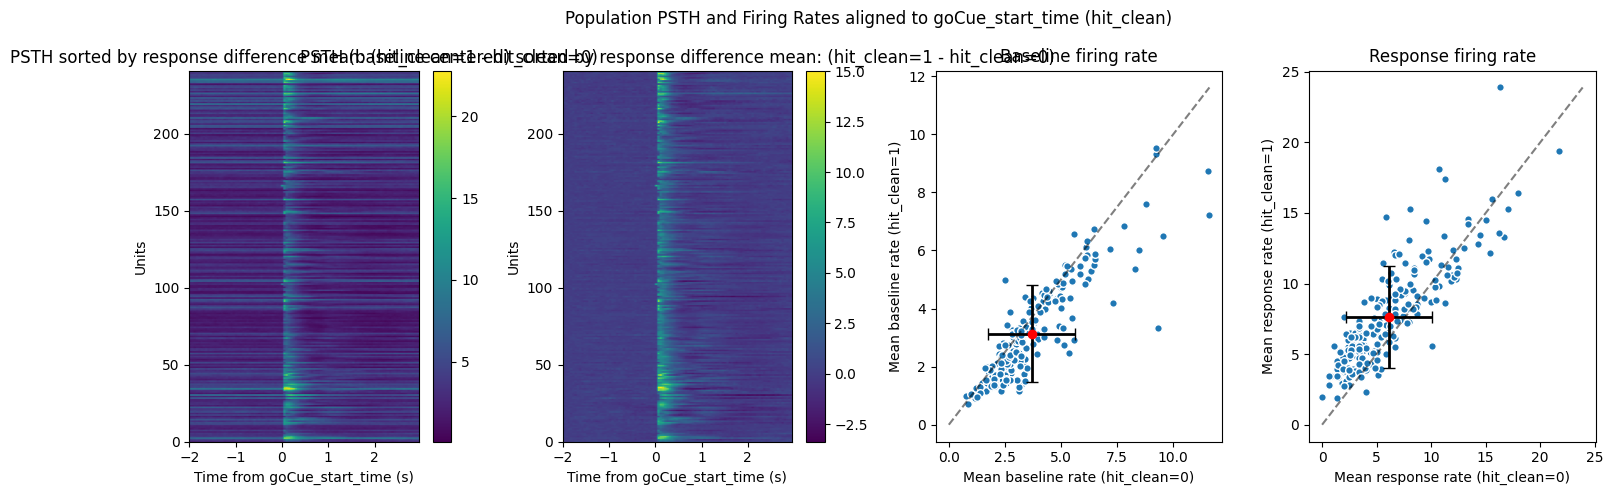

In [24]:
# plot_psth_and_cat_firing_rate(features_combined, 'hit', 'goCue_start_time', bl_win=(-2, 0.01), resp_win=(0.001, 0.5), target_folder=target_folder)
# plot_psth_and_cat_firing_rate(features_combined, 'svs', 'goCue_start_time', bl_win=(-2, 0.01), resp_win=(0.001, 0.5), target_folder=target_folder)
fig, axes, mean_1_baseline, mean_1_response, mean_0_baseline, mean_0_response, sessions, unit_ids, time = plot_psth_and_cat_firing_rate(features_combined, 'hit_clean', 'goCue_start_time', bl_win=(-2, 0.01), resp_win=(0.001, 0.3), target_folder=target_folder, panels=['Figure5b'])

save_panel_csv(columns_to_df(session=sessions, unit_id=unit_ids, respond_baseline=mean_1_baseline, ignore_baseline=mean_0_baseline, respond_response=mean_1_response, ignore_response=mean_0_response), target_folder, 'population_psth_and_firing_rates_hit_clean', ['Figure5b'])
##Figure5b##

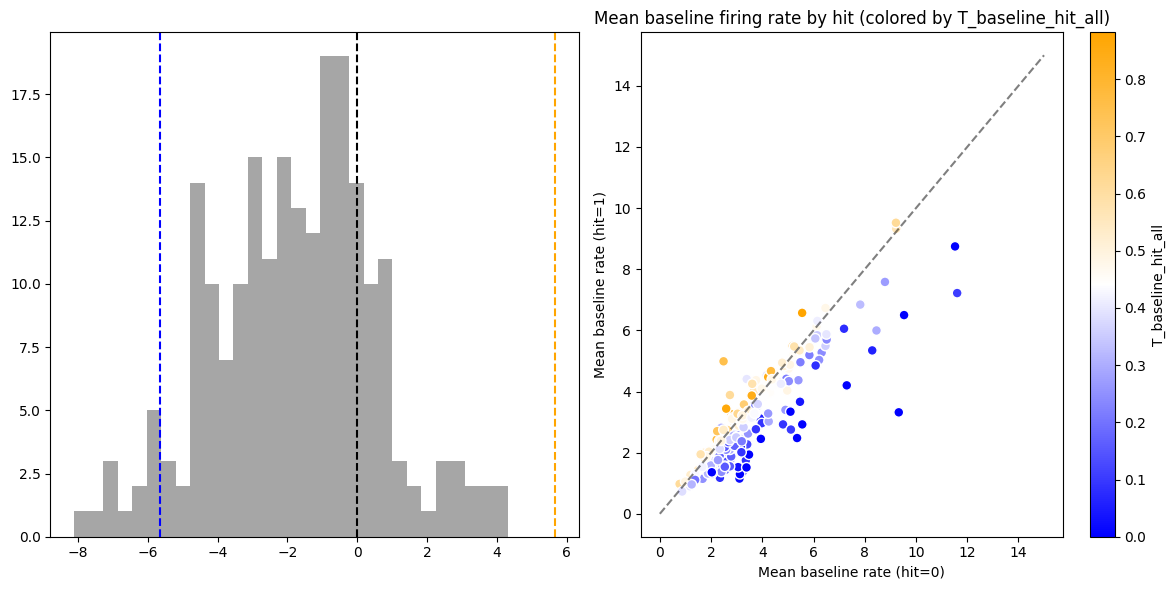

In [22]:
curr_df = pd.DataFrame({
    'session': sessions,
    'unit_id': unit_ids,
    'mean_1_baseline': mean_1_baseline,
    'mean_1_response': mean_1_response,
    'mean_0_baseline': mean_0_baseline,
    'mean_0_response': mean_0_response
})
color_code = 'T_baseline_hit_all'
curr_df['unit_id'] = curr_df['unit_id'].apply(to_str_intlike)
curr_df = curr_df.merge(response_tbl[['session', 'unit_id', color_code]], on=['session', 'unit_id'], how='left')
# scatter plot with color code
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# color by baseline rate
color = curr_df[color_code].values.astype(float)
color_reg = color.copy()

# === Normalize colors to 0–1 ===
amp_cut = np.nanquantile(np.abs(color_reg), 0.95)
color_reg = 0.5 + 0.5 * color_reg / amp_cut
color_reg = np.clip(color_reg, 0, 1)
center_line = 0
upper_limit = amp_cut
lower_limit = -amp_cut

ax = axes[0]
ax.hist(color, bins=30, color='gray', edgecolor='none', alpha=0.7)
ax.axvline(center_line, color='black', linestyle='--')
ax.axvline(upper_limit, c=feature_map[color_code](0.999999)[:3], linestyle='--')
ax.axvline(lower_limit, c=feature_map[color_code](0.000001)[:3], linestyle='--')


ax = axes[1]
sc = ax.scatter(
    curr_df['mean_0_baseline'],
    curr_df['mean_1_baseline'],
    c=color_reg,
    cmap=feature_map[color_code],
    edgecolor='white',
    s=50,
)
fig.colorbar(sc, ax=ax, label=color_code)
ax.plot([0, 15], [0, 15], 'k--', alpha=0.5)
ax.set_xlabel('Mean baseline rate (hit=0)')
ax.set_ylabel('Mean baseline rate (hit=1)')
ax.set_title(f'Mean baseline firing rate by hit (colored by {color_code})')

plt.tight_layout()
fig.savefig(fname=os.path.join(target_folder, f'mean_baseline_rate_by_hit_colored_by_{color_code}.pdf'))



['/root/capsule/scratch/results/manuscript/figures/F_ephys_beh_action&outcome/Figure5f_population_psth_and_firing_rates_svs.csv']

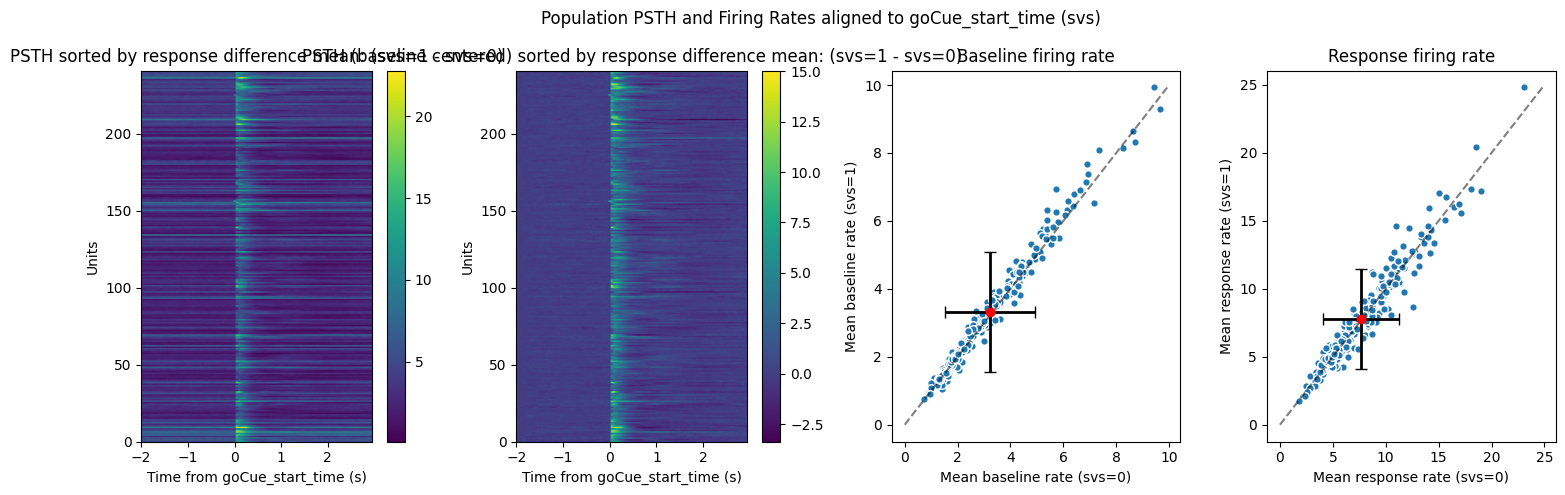

In [23]:
fig, axes, mean_1_baseline, mean_1_response, mean_0_baseline, mean_0_response, sessions, unit_ids, time = plot_psth_and_cat_firing_rate(features_combined, 'svs', 'goCue_start_time', bl_win=(-2, 0.01), resp_win=(0.001, 0.3), target_folder=target_folder, panels=['Figure5f'])

save_panel_csv(columns_to_df(session=sessions, unit_id=unit_ids, switch_baseline=mean_1_baseline, stay_baseline=mean_0_baseline, switch_response=mean_1_response, stay_response=mean_0_response), target_folder, 'population_psth_and_firing_rates_svs', ['Figure5f'])
##Figure5f##

## PSTH Analysis

Generate peri-stimulus time histograms (PSTHs) aligned to task events to visualize neural responses.

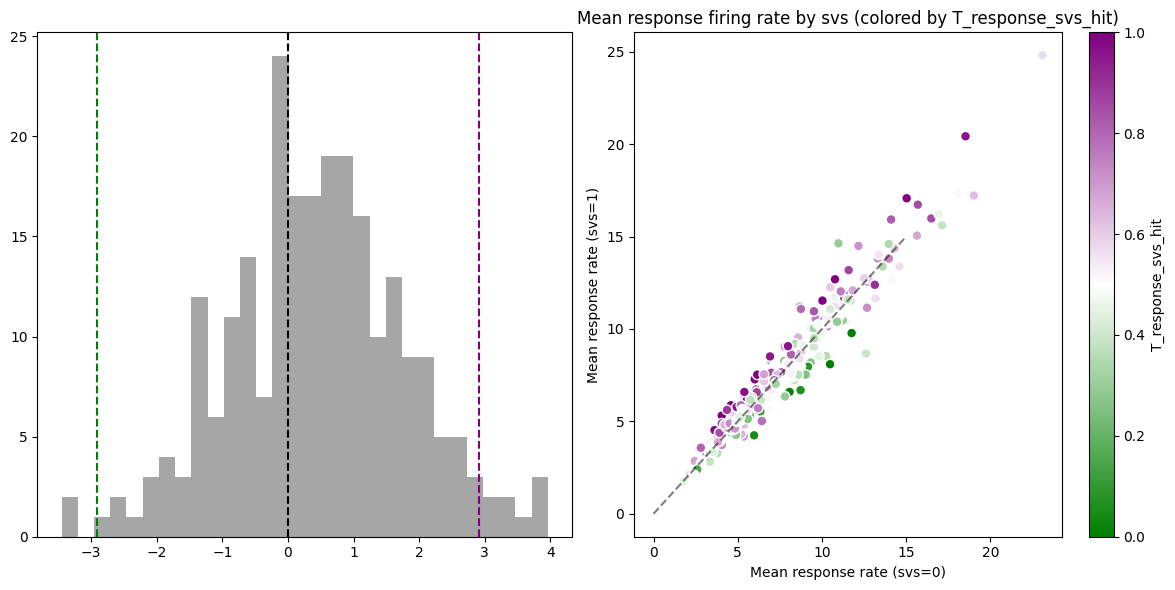

In [24]:
curr_df = pd.DataFrame({
    'session': sessions,
    'unit_id': unit_ids,
    'mean_1_baseline': mean_1_baseline,
    'mean_1_response': mean_1_response,
    'mean_0_baseline': mean_0_baseline,
    'mean_0_response': mean_0_response
})
color_code = 'T_response_svs_hit'
curr_df['unit_id'] = curr_df['unit_id'].apply(to_str_intlike)
curr_df = curr_df.merge(response_tbl[['session', 'unit_id', color_code]], on=['session', 'unit_id'], how='left')
# scatter plot with color code
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# color by baseline rate
color = curr_df[color_code].values.astype(float)
color_reg = color.copy()

# === Normalize colors to 0–1 ===
amp_cut = np.nanquantile(np.abs(color_reg), 0.95)
color_reg = 0.5 + 0.5 * color_reg / amp_cut
color_reg = np.clip(color_reg, 0, 1)
center_line = 0
upper_limit = amp_cut
lower_limit = -amp_cut

ax = axes[0]
ax.hist(color, bins=30, color='gray', edgecolor='none', alpha=0.7)
ax.axvline(center_line, color='black', linestyle='--')
ax.axvline(upper_limit, c=feature_map[color_code](0.999999)[:3], linestyle='--')
ax.axvline(lower_limit, c=feature_map[color_code](0.000001)[:3], linestyle='--')


ax = axes[1]
sc = ax.scatter(
    curr_df['mean_0_response'],
    curr_df['mean_1_response'],
    c=color_reg,
    cmap=feature_map[color_code],
    edgecolor='white',
    s=50,
)
fig.colorbar(sc, ax=ax, label=color_code)
ax.plot([0, 15], [0, 15], 'k--', alpha=0.5)
ax.set_xlabel('Mean response rate (svs=0)')
ax.set_ylabel('Mean response rate (svs=1)')
ax.set_title(f'Mean response firing rate by svs (colored by {color_code})')

plt.tight_layout()
fig.savefig(fname=os.path.join(target_folder, f'mean_response_rate_by_svs_colored_by_{color_code}.pdf'))



### outcome, svs and go miss auROC

In [25]:
# perform auc on sliding window and define best window for each unit
def population_auc_analysis(combined_tagged_units_filtered, target_folder, label, align = 'outcome_time',
                            pre_event = -0.5, post_event = 2, binSize = 1.5, stepSize = 0.1):

    auc_mat = []           
    auc_max = []
    auc_max_ind = []
    loaded_session = None
    curr_session = None
    data_type = 'curated'
    model_name = 'stan_qLearning_5params'
    for ind, row in combined_tagged_units_filtered.iterrows():
        session = row['session']                           
        unit_id = row['unit_id']
        # convert to numeric if possible for matching with unit_tbl
        unit_id = float(unit_id) if float(unit_id).is_integer() else unit_id
        print(session)
        if loaded_session is None or loaded_session != session:
            session_dir = session_dirs(session)
            unit_tbl = get_unit_tbl(session, data_type)
            session_df = makeSessionDF(session, model_name = model_name)
            session_df['ipsi'] = 2*(session_df['choice'].values - 0.5) * row['rec_side']
            drift_data = load_trial_drift(session, data_type)
            loaded_session = session
        unit_drift = load_drift(session, unit_id, data_type=data_type)  
        spike_times = unit_tbl.query('unit_id == @unit_id')['spike_times'].values[0]
        session_df_curr = session_df.copy()
        spike_times_curr = spike_times.copy()
        unit_trial_drift_curr = drift_data.load_unit(unit_id)
        # tblTrials_curr = tblTrials.copy()
        if unit_drift is not None:
            if unit_drift['ephys_cut'][0] is not None:
                spike_times_curr = spike_times_curr[spike_times_curr >= unit_drift['ephys_cut'][0]]
                session_df_curr = session_df_curr[session_df_curr['go_cue_time'] >= unit_drift['ephys_cut'][0]]
                # tblTrials_curr = tblTrials_curr[tblTrials_curr['goCue_start_time'] >= unit_drift['ephys_cut'][0]]
            if unit_drift['ephys_cut'][1] is not None:
                spike_times_curr = spike_times_curr[spike_times_curr <= unit_drift['ephys_cut'][1]]
                session_df_curr = session_df_curr[session_df_curr['go_cue_time'] <= unit_drift['ephys_cut'][1]]
                # tblTrials_curr = tblTrials_curr[tblTrials_curr['goCue_start_time'] <= unit_drift['ephys_cut'][1]]
        if len(session_df_curr) < 5:
            auc_mat.append(None)
            auc_max.append(np.nan)
            auc_max_ind.append(np.nan)
            continue
        align_time = session_df_curr['outcome_time'].values
        spike_matrix_auc, slide_times_auc = get_spike_matrix(spike_times_curr, align_time, 
                                                    pre_event=pre_event, post_event=post_event, 
                                                    binSize=binSize, stepSize=stepSize, kernel=True,
                                                    tau_rise=0.001, tau_decay=0.08)
        curr_auc = np.full(len(slide_times_auc), np.nan, dtype=float)
        for time_ind, time in enumerate(slide_times_auc):
            # get the spike counts in the sliding window
            spike_counts = spike_matrix_auc[:, time_ind]
            # outcome
            focus = session_df_curr[label].values
            curr_auc[time_ind] = roc_auc_score(focus, spike_counts)
        
        curr_max_ind = np.nanargmax(np.abs(curr_auc-0.5), axis=0)
        curr_max = curr_auc[curr_max_ind]

        auc_mat.append(curr_auc)
        auc_max.append(curr_max)
        auc_max_ind.append(curr_max_ind)
    auc_max = np.array(auc_max)
    auc_max_ind = np.array(auc_max_ind)
    auc_results = {
        'auc_mat': auc_mat,
        'auc_max': auc_max,
        'auc_max_ind': auc_max_ind,
        'slide_times_auc': slide_times_auc
    }
    
    # plot as colorcode matrix
    fig, axes = plt.subplots(1, len(labels), figsize=(5*len(labels), 5))
    for label_ind, label in enumerate(labels):
        auc_mat_label = np.array([auc[label_ind] if auc is not None else np.full((len(labels)), np.nan) for auc in auc_mat])
        im = axes[label_ind].imshow(auc_mat_label, aspect='auto', extent=[slide_times_auc[0], slide_times_auc[-1], 0, len(auc_mat)], vmin=0, vmax=1, cmap='viridis')
        fig.colorbar(im, ax=axes[label_ind])
        axes[label_ind].set_title(f'AUC over time for {label}')
        axes[label_ind].set_xlabel('Time from outcome (s)')
        axes[label_ind].set_ylabel('Units')
    plt.tight_layout()
    fig.savefig(os.path.join(target_folder, f'population_auc_{label}.pdf'))
    fig.savefig(os.path.join(target_folder, f'population_auc_{label}.svg'))
    # also plot distribution of max AUC values
    fig, axes = plt.subplots(1, len(labels), figsize=(5*len(labels), 5))
    for label_ind, label in enumerate(labels):
        auc_max_label = auc_max[:, label_ind]
        axes[label_ind].hist(auc_max_label[~np.isnan(auc_max_label)], bins=20, range=(0, 1))
        axes[label_ind].set_title(f'Distribution of max AUC values for {label}')
        axes[label_ind].set_xlabel('Max AUC value')
        axes[label_ind].set_ylabel('Number of units')
    plt.tight_layout()
    fig.savefig(os.path.join(target_folder, f'population_auc_max_distribution_{label}.pdf'))
    fig.savefig(os.path.join(target_folder, f'population_auc_max_distribution_{label}.svg'))
    


In [26]:
import numpy as np
from joblib import Parallel, delayed
from sklearn.metrics import roc_auc_score

# --- per-process cache (each worker process keeps its own dict) ---
_SESSION_CACHE = {}

def is_number(s):
    try:
        float(s)
        return True
    except (TypeError, ValueError):
        return False

def _get_session_cache(session, data_type="curated", model_name="stan_qLearning_5params"):
    """
    Load session-level objects once per worker-process (best-effort caching).
    """
    key = (session, data_type, model_name)
    if key not in _SESSION_CACHE:
        unit_tbl = get_unit_tbl(session, data_type)
        session_df = get_session_tbl(session)
        session_df['hit'] = (session_df['animal_response'] != 2).astype(int)
        session_df['hit_clean'] = session_df['hit'].copy()
        session_df.loc[session_df['rewarded_historyL'] | session_df['rewarded_historyR'], 'hit_clean'] = np.nan
        # all choice times 
        session_df['choice_time'] = np.nan
        session_df.loc[session_df['animal_response'] != 2, 'choice_time'] = session_df.loc[session_df['animal_response'] != 2, 'reward_outcome_time']
        # all reward times
        session_df['reward_time'] = session_df['choice_time'] +  np.unique(session_df[~session_df['reward_delay'].isnull()]['reward_delay'])[0]
        # go cue times
        session_df['go_cue_time'] = session_df['goCue_start_time']
        # outcome
        session_df['outcome'] = np.nan
        session_df.loc[session_df['animal_response'] != 2, 'outcome'] = 0
        session_df.loc[session_df['rewarded_historyL'] | session_df['rewarded_historyR'], 'outcome'] = 1
        # stay vs switch
        session_df['svs'] = np.nan
        choices = session_df[session_df['animal_response'] != 2]['animal_response'].values
        switch = np.insert(choices[1:] != choices[:-1], 0, False)
        session_df.loc[session_df['animal_response'] != 2, 'svs'] = switch.astype(int)

        drift_data = load_trial_drift(session, data_type)
        _SESSION_CACHE[key] = (unit_tbl, session_df, drift_data)
    return _SESSION_CACHE[key]


def _auc_one_session_unit(
    session,
    unit_id,
    rec_side,
    label,
    *,
    align="outcome_time",
    pre_event=-0.5,
    post_event=2,
    binSize=1.5,
    stepSize=0.1,
    data_type="curated",
    model_name="stan_qLearning_5params",
    kernel=True,
    tau_rise=0.001,
    tau_decay=0.2,
):
    # ensure unit_id matches your unit_tbl keys
    if is_number(unit_id):
        unit_id_key = float(unit_id)
    else:
        unit_id_key = unit_id

    unit_tbl, session_df, drift_data = _get_session_cache(session, data_type=data_type, model_name=model_name)
    if unit_tbl is None or session_df is None:
        return None, np.nan, np.nan, None, session, unit_id_key

    # per-unit ipsi
    session_df_curr = session_df.copy()
    # session_df_curr["ipsi"] = 2 * (session_df_curr["choice"].values - 0.5) * rec_side

    # pull spike times
    rows = unit_tbl.query("unit_id == @unit_id_key")
    if len(rows) == 0:
        return None, np.nan, np.nan, None, session, unit_id_key
    spike_times = np.asarray(rows["spike_times"].values[0])

    # apply per-unit drift cuts
    unit_drift = load_drift(session, unit_id_key, data_type=data_type)
    spike_times_curr = spike_times.copy()

    if unit_drift is not None and "ephys_cut" in unit_drift:
        t0, t1 = unit_drift["ephys_cut"]
        if t0 is not None:
            spike_times_curr = spike_times_curr[spike_times_curr >= t0]
            session_df_curr = session_df_curr[session_df_curr["go_cue_time"] >= t0]
        if t1 is not None:
            spike_times_curr = spike_times_curr[spike_times_curr <= t1]
            session_df_curr = session_df_curr[session_df_curr["go_cue_time"] <= t1]

    if len(session_df_curr) < 5:
        return None, np.nan, np.nan, None, session, unit_id_key

    # align times
    align_time = session_df_curr[align].values
    focus = session_df_curr[label].values
    # roc_auc_score needs both classes
    valid_mask = ~np.isnan(focus) & np.isfinite(focus) & ~np.isnan(align_time) & np.isfinite(align_time)
    ok_focus = focus[valid_mask]
    align_time = align_time[valid_mask]


    spike_matrix_auc, slide_times_auc = get_spike_matrix(
        spike_times_curr,
        align_time,
        pre_event=pre_event,
        post_event=post_event,
        binSize=binSize,
        stepSize=stepSize,
        kernel=kernel,
        tau_rise=tau_rise,
        tau_decay=tau_decay
    )

    # focus = session_df_curr[label].values

    # # roc_auc_score needs both classes
    # ok_focus = np.isfinite(focus)
    if np.unique(ok_focus).size < 2:
        return None, np.nan, np.nan, slide_times_auc, session, unit_id_key

    curr_auc = np.full(len(slide_times_auc), np.nan, dtype=float)
    for t in range(len(slide_times_auc)):
        scores = spike_matrix_auc[:, t]
        ok = np.isfinite(scores) & np.isfinite(ok_focus)
        if ok.sum() < 3 or np.unique(ok_focus[ok]).size < 2:
            continue
        try:
            curr_auc[t] = roc_auc_score(ok_focus[ok], scores[ok])
        except Exception:
            curr_auc[t] = np.nan

    if np.all(~np.isfinite(curr_auc)):
        return curr_auc, np.nan, np.nan, slide_times_auc, session, unit_id_key

    best_ind = int(np.nanargmax(np.abs(curr_auc - 0.5)))
    best_auc = float(curr_auc[best_ind])

    return curr_auc, best_auc, best_ind, slide_times_auc, session, unit_id_key


def population_auc_analysis_parallel_by_session_unit(
    combined_tagged_units_filtered,
    *,
    label,
    align="choice_time",
    pre_event=-0.5,
    post_event=2,
    binSize=1,
    stepSize=0.1,
    n_jobs=-1,
    kernel=True,
    tau_rise=0.001,
    tau_decay=0.2,
):
    # build tasks: one per (session, unit)
    tasks = []
    for _, row in combined_tagged_units_filtered.iterrows():
        tasks.append((
            row["session"],
            row["unit_id"],
            row["rec_side"],
        ))

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_auc_one_session_unit)(
            session, unit_id, rec_side,
            label,
            align=align,
            pre_event=pre_event,
            post_event=post_event,
            binSize=binSize,
            stepSize=stepSize,
            kernel=kernel,
            tau_decay=0.2,
            tau_rise=0.001,
        )
        for (session, unit_id, rec_side) in tasks
    )
    # results = []
    # for (session, unit_id, rec_side) in tasks:
    #     print(f"Processing session {session}, unit {unit_id}...")
    #     r = _auc_one_session_unit(
    #         session, unit_id, rec_side,
    #         label,
    #         align=align,
    #         pre_event=pre_event,
    #         post_event=post_event,
    #         binSize=binSize,
    #         stepSize=stepSize,
    #         kernel=kernel,
    #         tau_decay=tau_decay,
    #         tau_rise=tau_rise,
    #     )
    #     results.append(r)

    # collect
    auc_mat = []
    auc_max = []
    auc_max_ind = []
    slide_times_auc = None
    sessions_out = []
    units_out = []

    for curr_auc, best_auc, best_ind, st, session, unit_id in results:
        auc_mat.append(curr_auc)
        auc_max.append(best_auc)
        auc_max_ind.append(best_ind)
        sessions_out.append(session)
        units_out.append(unit_id)
        if slide_times_auc is None and st is not None:
            slide_times_auc = st

    return {
        "auc_mat": auc_mat,
        "auc_max": np.asarray(auc_max, float),
        "auc_max_ind": np.asarray(auc_max_ind, float),
        "slide_times_auc": slide_times_auc,
        "session": np.asarray(sessions_out, object),
        "unit_id": np.asarray(units_out, object),
    }


## ROC/AUC Analysis: Response Selectivity

Perform receiver operating characteristic (ROC) analysis using a sliding window to identify the optimal time window where neurons discriminate between conditions (e.g., hit vs. miss). The area under the ROC curve (AUC) quantifies discrimination performance.

In [27]:
results_outcome = population_auc_analysis_parallel_by_session_unit(combined_tagged_units_filtered, label='outcome', align='reward_time', kernel=True, tau_decay=0.2, stepSize=0.05)

In [28]:
results_hit = population_auc_analysis_parallel_by_session_unit(combined_tagged_units_filtered, label='hit', align='go_cue_time', kernel=True, tau_decay=0.8, pre_event=-0.5, post_event=0.5, stepSize=0.05)
results_svs = population_auc_analysis_parallel_by_session_unit(combined_tagged_units_filtered, label='svs', align='go_cue_time', kernel=True, tau_decay=0.8, pre_event=-0.5, post_event=0.5, stepSize=0.05)
results_hit_clean = population_auc_analysis_parallel_by_session_unit(combined_tagged_units_filtered, label='hit_clean', align='go_cue_time', kernel=True, tau_decay=0.8, pre_event=-0.5, post_event=0.5, stepSize=0.05)

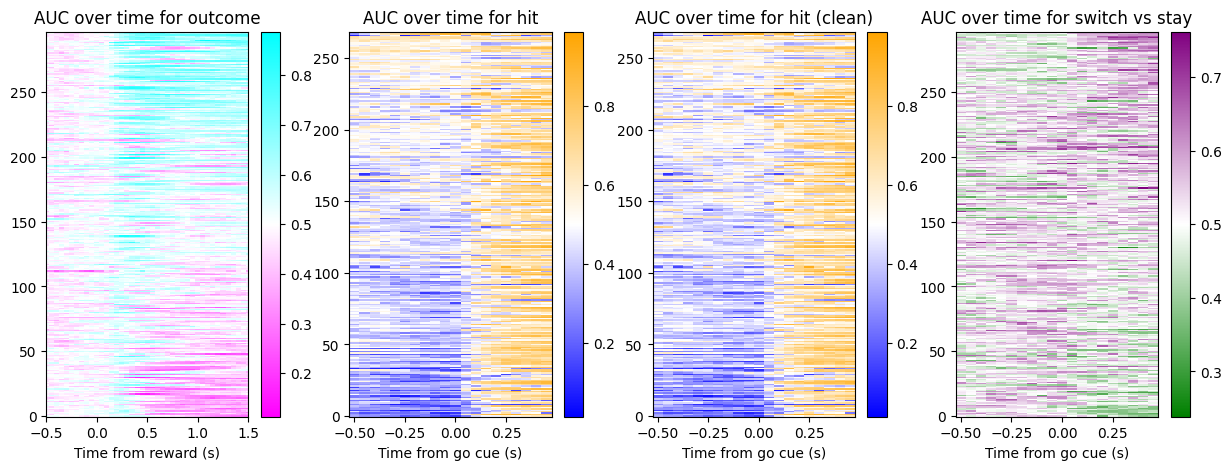

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

mask = np.array([x is not None for x in results_outcome["auc_mat"]])
auc_mat = np.vstack([
    a for a, m in zip(results_outcome["auc_mat"], mask) if m
])
slide_times_auc = results_outcome["slide_times_auc"]
# recompute sort_inds based on max AUC values with slide times after 0
# for each unit, session and unit_id, get the corresponding T_outcome_com_mc value from feature_combined and use that for sorting
unit_sessions = results_outcome["session"]
unit_ids = results_outcome["unit_id"]
unit_features = []
for session, unit_id in zip(unit_sessions, unit_ids):
    unit_id = to_str_intlike(unit_id)
    row = features_combined[(features_combined["session"] == session) & (features_combined["unit_id"] == unit_id)]
    if len(row) == 0:
        unit_features.append(np.nan)
    else:
        unit_features.append(row["T_outcome_com_mc"].values[0])
sort_inds = np.argsort(unit_features)
max_mag = np.nanmax(np.abs(auc_mat - 0.5))
# im = axes[0].imshow(
#     auc_mat[sort_inds, :],
#     aspect="auto",
#     extent=[slide_times_auc[0], slide_times_auc[-1], 0, auc_mat.shape[0]],
#     vmin=0.5 - max_mag,
#     vmax=0.5 + max_mag,
#     cmap=feature_map['T_outcome_com_mc'],
#     interpolation="none"
# )
C = auc_mat[sort_inds, :]
im = axes[0].pcolormesh(
    slide_times_auc,
    np.arange(C.shape[0]),
    C,
    cmap=feature_map['T_outcome_com_mc'],
    vmin=0.5 - max_mag,
    vmax=0.5 + max_mag,
    shading='nearest'
)


axes[0].set_xlabel('Time from reward (s)')
axes[0].set_xlim(-0.5, 1.5)
plt.colorbar(im, ax=axes[0])
axes[0].set_title(f"AUC over time for outcome")

# filter for valid units with non-nan AUC values and valid slide times
mask = np.array([x is not None for x in results_hit["auc_mat"]])
auc_mat = np.vstack([
    a for a, m in zip(results_hit["auc_mat"], mask) if m
])
slide_times_auc = results_hit["slide_times_auc"]
# for each unit, session and unit_id, get the corresponding T_outcome_com_mc value from feature_combined and use that for sorting
unit_sessions = results_outcome["session"]
unit_ids = results_outcome["unit_id"]
unit_features = []
for session, unit_id in zip(unit_sessions, unit_ids):
    unit_id = to_str_intlike(unit_id)
    row = features_combined[(features_combined["session"] == session) & (features_combined["unit_id"] == unit_id)]
    if len(row) == 0:
        unit_features.append(np.nan)
    else:
        unit_features.append(row["T_baseline_hit_all"].values[0])
sort_inds = np.argsort(np.array(unit_features)[mask])
max_mag = np.nanmax(np.abs(auc_mat - 0.5)) 
# im = axes[1].imshow(
#     auc_mat[sort_inds, :],
#     aspect="auto",
#     extent=[slide_times_auc[0], slide_times_auc[-1], 0, auc_mat.shape[0]],
#     vmin=0.5 - max_mag,
#     vmax=0.5 + max_mag,
#     cmap=feature_map['T_baseline_hit_all'],
#     interpolation="none"
# )
C = auc_mat[sort_inds, :]
im = axes[1].pcolormesh(
    slide_times_auc,
    np.arange(C.shape[0]),
    C,
    cmap=feature_map['T_baseline_hit_all'],
    vmin=0.5 - max_mag,
    vmax=0.5 + max_mag,
    shading='nearest'
)

plt.colorbar(im, ax=axes[1])
axes[1].set_title(f"AUC over time for hit")
axes[1].set_xlabel('Time from go cue (s)')
# filter

mask = np.array([x is not None for x in results_hit_clean["auc_mat"]])
auc_mat = np.vstack([
    a for a, m in zip(results_hit_clean["auc_mat"], mask) if m
])
slide_times_auc = results_hit_clean["slide_times_auc"]
# for each unit, session and unit_id, get the corresponding T_outcome_com_mc value from feature_combined and use that for sorting
unit_sessions = results_outcome["session"]
unit_ids = results_outcome["unit_id"]
unit_features = []
for session, unit_id in zip(unit_sessions, unit_ids):
    unit_id = to_str_intlike(unit_id)
    row = features_combined[(features_combined["session"] == session) & (features_combined["unit_id"] == unit_id)]
    if len(row) == 0:
        unit_features.append(np.nan)
    else:
        unit_features.append(row["T_baseline_hit_all"].values[0])
sort_inds = np.argsort(np.array(unit_features)[mask])
max_mag = np.nanmax(np.abs(auc_mat - 0.5))
# im = axes[2].imshow(
#     auc_mat[sort_inds, :],
#     aspect="auto",
#     extent=[slide_times_auc[0], slide_times_auc[-1], 0, auc_mat.shape[0]],
#     vmin=0.5 - max_mag,
#     vmax=0.5 + max_mag,
#     cmap=feature_map['T_baseline_hit_all'],
#     interpolation="none"
# )

C = auc_mat[sort_inds, :]
im = axes[2].pcolormesh(
    slide_times_auc,
    np.arange(C.shape[0]),
    C,
    cmap=feature_map['T_baseline_hit_all'],
    vmin=0.5 - max_mag,
    vmax=0.5 + max_mag,
    shading='nearest'
)
plt.colorbar(im, ax=axes[2])
axes[2].set_title(f"AUC over time for hit (clean)")
axes[2].set_xlabel('Time from go cue (s)')



# filter for valid units with non-nan AUC values and valid slide times
mask = np.array([x is not None for x in results_svs["auc_mat"]])
auc_mat = np.vstack([
    a for a, m in zip(results_svs["auc_mat"], mask) if m
])
slide_times_auc = results_svs["slide_times_auc"]
# for each unit, session and unit_id, get the corresponding T_outcome_com_mc value from feature_combined and use that for sorting
unit_sessions = results_outcome["session"]
unit_ids = results_outcome["unit_id"]
unit_features = []

for session, unit_id in zip(unit_sessions, unit_ids):
    unit_id = to_str_intlike(unit_id)
    row = features_combined[(features_combined["session"] == session) & (features_combined["unit_id"] == unit_id)]
    if len(row) == 0:
        unit_features.append(np.nan)
    else:
        unit_features.append(row["T_response_svs_hit"].values[0])
sort_inds = np.argsort(np.array(unit_features)[mask])
max_mag = np.nanmax(np.abs(auc_mat - 0.5))
# im = axes[3].imshow(
#     auc_mat[sort_inds, :],
#     aspect="auto",
#     extent=[slide_times_auc[0], slide_times_auc[-1], 0, auc_mat.shape[0]],
#     vmin=0.5 - max_mag, 
#     vmax=0.5 + max_mag,
#     cmap=feature_map['T_baseline_svs_hit'],
#     interpolation="none"
# )
# im = axes[3].pcolormesh(
#     slide_times_auc,
#     np.arange(auc_mat.shape[0] + 1),
#     auc_mat[sort_inds, :],
#     cmap=feature_map['T_baseline_svs_hit'],
#     vmin=0.5 - max_mag,
#     vmax=0.5 + max_mag,
#     shading='nearest'
# )
C = auc_mat[sort_inds, :]

im = axes[3].pcolormesh(
    slide_times_auc,
    np.arange(C.shape[0]),
    C,
    cmap=feature_map['T_baseline_svs_hit'],
    vmin=0.5 - max_mag,
    vmax=0.5 + max_mag,
    shading='nearest'
)
plt.colorbar(im, ax=axes[3])
axes[3].set_title(f"AUC over time for switch vs stay")
axes[3].set_xlabel('Time from go cue (s)')
# save
save_panels(fig, target_folder, f'population_auc_timecourse', ['FigureS15a-c'], exts=('pdf',))
# ---- panel CSVs (heatmap: auROC matrix, time as columns, unit as row index; rule 9: a=respond-ignore, b=switch-stay, c=reward-noreward) ----
for _panel, _res in [('FigureS15a', results_hit_clean), ('FigureS15b', results_svs), ('FigureS15c', results_outcome)]:
    _mk = np.array([x is not None for x in _res['auc_mat']])
    _mat = np.vstack([a for a, m in zip(_res['auc_mat'], _mk) if m])
    _units = [f"{s}_{u}" for s, u, m in zip(_res['session'], _res['unit_id'], _mk) if m]
    save_panel_csv(heatmap_to_df(_mat, _res['slide_times_auc'], _units), target_folder, 'population_auc_timecourse', [_panel], index=True)
##FigureS15a-c##

# Basic ephys features

['/root/capsule/scratch/results/manuscript/figures/F_ephys_beh_action&outcome/Figure4g_response_fr_vs_bl_mean_color-code_p_value_bl_response.csv']

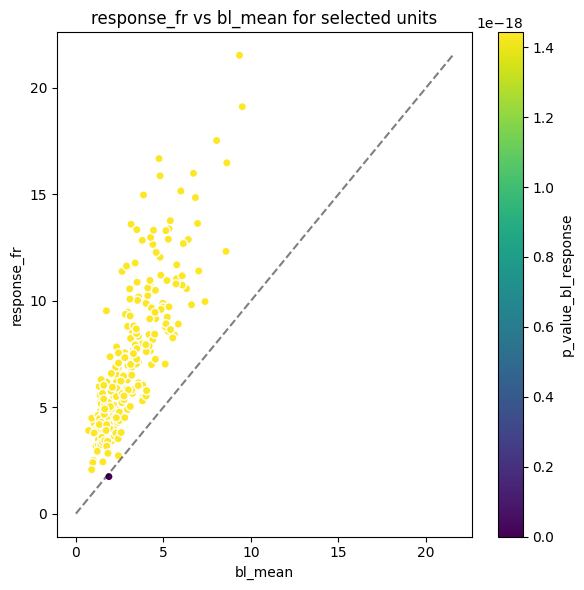

In [30]:
x_val = 'bl_mean'
y_val = 'response_fr'
color_code = 'p_value_bl_response'


mask = features_combined['selected'].values.astype(bool)
color_values = features_combined[color_code].values[mask]
sort_inds = np.argsort(color_values)
plt.figure(figsize=(6, 6))
sg = plt.scatter(features_combined.loc[mask, x_val].values[sort_inds], features_combined.loc[mask, y_val].values[sort_inds], 
            c = features_combined.loc[mask, color_code].values[sort_inds]<=0.05, vmax=features_combined.loc[mask, color_code].quantile(0.95), cmap='viridis',
            alpha=1, edgecolors='white')
# colorbar
cbar = plt.colorbar(sg, label=color_code)
plt.xlabel(x_val)
plt.ylabel(y_val)
# diagonal line
max_val = max(features_combined.loc[mask, x_val].max(), features_combined.loc[mask, y_val].max())
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
plt.title(f'{y_val} vs {x_val} for selected units')

# save
plt.tight_layout()
save_panels(fig, target_folder, f'{y_val}_vs_{x_val}_color-code_{color_code}', ['Figure4g'], exts=('pdf',))

# ---- panel CSV (rule 1 scatter) ----
_m = features_combined['selected'].values.astype(bool)
save_panel_csv(columns_to_df(**{x_val: features_combined.loc[_m, x_val].values, y_val: features_combined.loc[_m, y_val].values, color_code: features_combined.loc[_m, color_code].values}), target_folder, f'{y_val}_vs_{x_val}_color-code_{color_code}', ['Figure4g'])
##Figure4g##

In [31]:
print(f'{np.sum(color_values<0.05)} cells are significant')
print(f'{np.sum(color_values>=0.05)} cells are not significant')

240 cells are significant
1 cells are not significant


# Plot features in space

In [32]:
# Comparision between new and old meshes
ml, ap, dv = 0, 1, 2
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # in mm
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}
norm = Normalize(vmin=0, vmax=1)
# mesh_old = load_mesh(str(capsule_directories()['derived_dir']) + '/combined/ccf_maps/20250418_transformed_remesh_10_ccf25.obj')
# mesh_vertices = np.array(mesh_old.vertices)
# mesh_vertices = (mesh_vertices - np.array([216, 18, 228]))*25/1000
# mesh_vertices_lps = pir_to_lps(mesh_vertices) # convert to lps
# mesh_vertices_mm = mesh_vertices_lps
# mesh_contours_old = {
#     plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
#     for plane_name, plane_axes in planes.items()
# }


mesh = load_mesh(mesh_file)
mesh_vertices = np.array(mesh.vertices)
mesh_vertices = mesh_vertices/1000
if 'scratch' in mesh_file:
    mesh_vertices = (mesh_vertices - np.array([216, 18, 228]))*25/1000
    mesh_vertices_lps = pir_to_lps(mesh_vertices) # convert to lps
    mesh_vertices_mm = mesh_vertices_lps
else:
    mesh_vertices_mm = mesh_vertices.copy()
    mesh_vertices_mm[:, 2] = -mesh_vertices_mm[:, 2]
    mesh_vertices_mm[:, 0] = -mesh_vertices_mm[:, 0]
    # mesh_vertices_mm = mesh_vertices[:, [0, 1, 2]]
    mesh_vertices_mm = mesh_vertices_mm - bregma_LPS_mm
mesh_vertices_mm[:, ml] = np.abs(mesh_vertices_mm[:, ml])

In [33]:
ml, ap, dv = 0, 1, 2
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}

norm = Normalize(vmin=0, vmax=1)

# --- 3D anatomical points ---
ccfs = features_combined[['x_ccf', 'y_ccf', 'z_ccf']].values
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # in mm
ccfs = ccfs - bregma_LPS_mm
ccfs[:, ml] = np.abs(ccfs[:, ml])  # mirror ML to left hemisphere

In [34]:
# precompute mesh contours for each plane (for speed)
mesh_contours = {
    plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
    for plane_name, plane_axes in planes.items()
}

## Anatomical Distribution of Neurons

Visualize the spatial distribution of functionally-defined neurons in brain space. This section maps outcome-selective and Q-value-selective neurons to their anatomical locations in prelimbic cortex (PrL) and primary somatosensory cortex (S1).

In [35]:
# colormaps
reward_colors = LinearSegmentedColormap.from_list('outcome', [(0.0, 'magenta'), (0.5, 'white'), (1.0, 'cyan')])
hit_colors = LinearSegmentedColormap.from_list('hit', [(0.0, 'blue'), (0.5, 'white'), (1.0, 'orange')])
switch_colors = LinearSegmentedColormap.from_list('switch', [(0.0, 'green'), (0.5, 'white'), (1.0, 'purple')])

In [36]:
feature_map = {
    'T_baseline_svs_hit': switch_colors,
    'T_response_svs_hit': switch_colors,
    'T_outcome_com_mc': reward_colors,
    'T_outcome_l_mc': reward_colors, 
    'T_baseline_hit_all': hit_colors, 
    'T_response_hit_all': hit_colors
    }

In [37]:
# perform spatial dependence analysis for all features
mask = features_combined['selected'].values
spatial_dependence_results = {}
# 20 for default
for feature_name, _ in feature_map.items():
    values = features_combined[feature_name].values
    result = spatial_dependence_summary(
        ccfs[mask, :],
        values[mask],
        k_neighbors=20,
        n_splits=5,
        permutations=10000,
        seed=42,
    )
    spatial_dependence_results[feature_name] = result


In [38]:
# k_neighbors = [10, 15, 20, 25, 30, 35, 40, 45, 50]
# test_results = []
# for k in k_neighbors:
#     values = features_combined['T_response_svs_hit'].values
#     result = spatial_dependence_summary(
#         ccfs[mask, :],
#         values[mask],
#         k_neighbors=k,
#         n_splits=5,
#         permutations=10000,
#         seed=42,
#     )
#     test_results.append((k, result['cv_predictability_knn']['p_value_permutation']))

In [39]:
# multiple comparison correction (FDR)
from statsmodels.stats.multitest import multipletests
# for knn
p_values = [spatial_dependence_results[feat]['cv_predictability_knn']['p_value_permutation'] for feat in feature_map.keys()]
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
for i, feature_name in enumerate(feature_map.keys()):
    spatial_dependence_results[feature_name]['cv_predictability_knn']['p_value_permutation_fdr'] = pvals_corrected[i]
    spatial_dependence_results[feature_name]['cv_predictability_knn']['significant_fdr'] = reject[i]
# for trend
p_values = [spatial_dependence_results[feat]['linear_trend']['p_value_permutation_r2'] for feat in feature_map.keys()]
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
for i, feature_name in enumerate(feature_map.keys()):
    spatial_dependence_results[feature_name]['linear_trend']['p_value_permutation_r2_fdr'] = pvals_corrected[i]
    spatial_dependence_results[feature_name]['linear_trend']['significant_fdr'] = reject[i]
# save results
output_file = os.path.join(target_folder, f'spatial_dependence_results_{criteria_name}.pkl')
with open(output_file, 'wb') as f:
    pickle.dump(spatial_dependence_results, f)

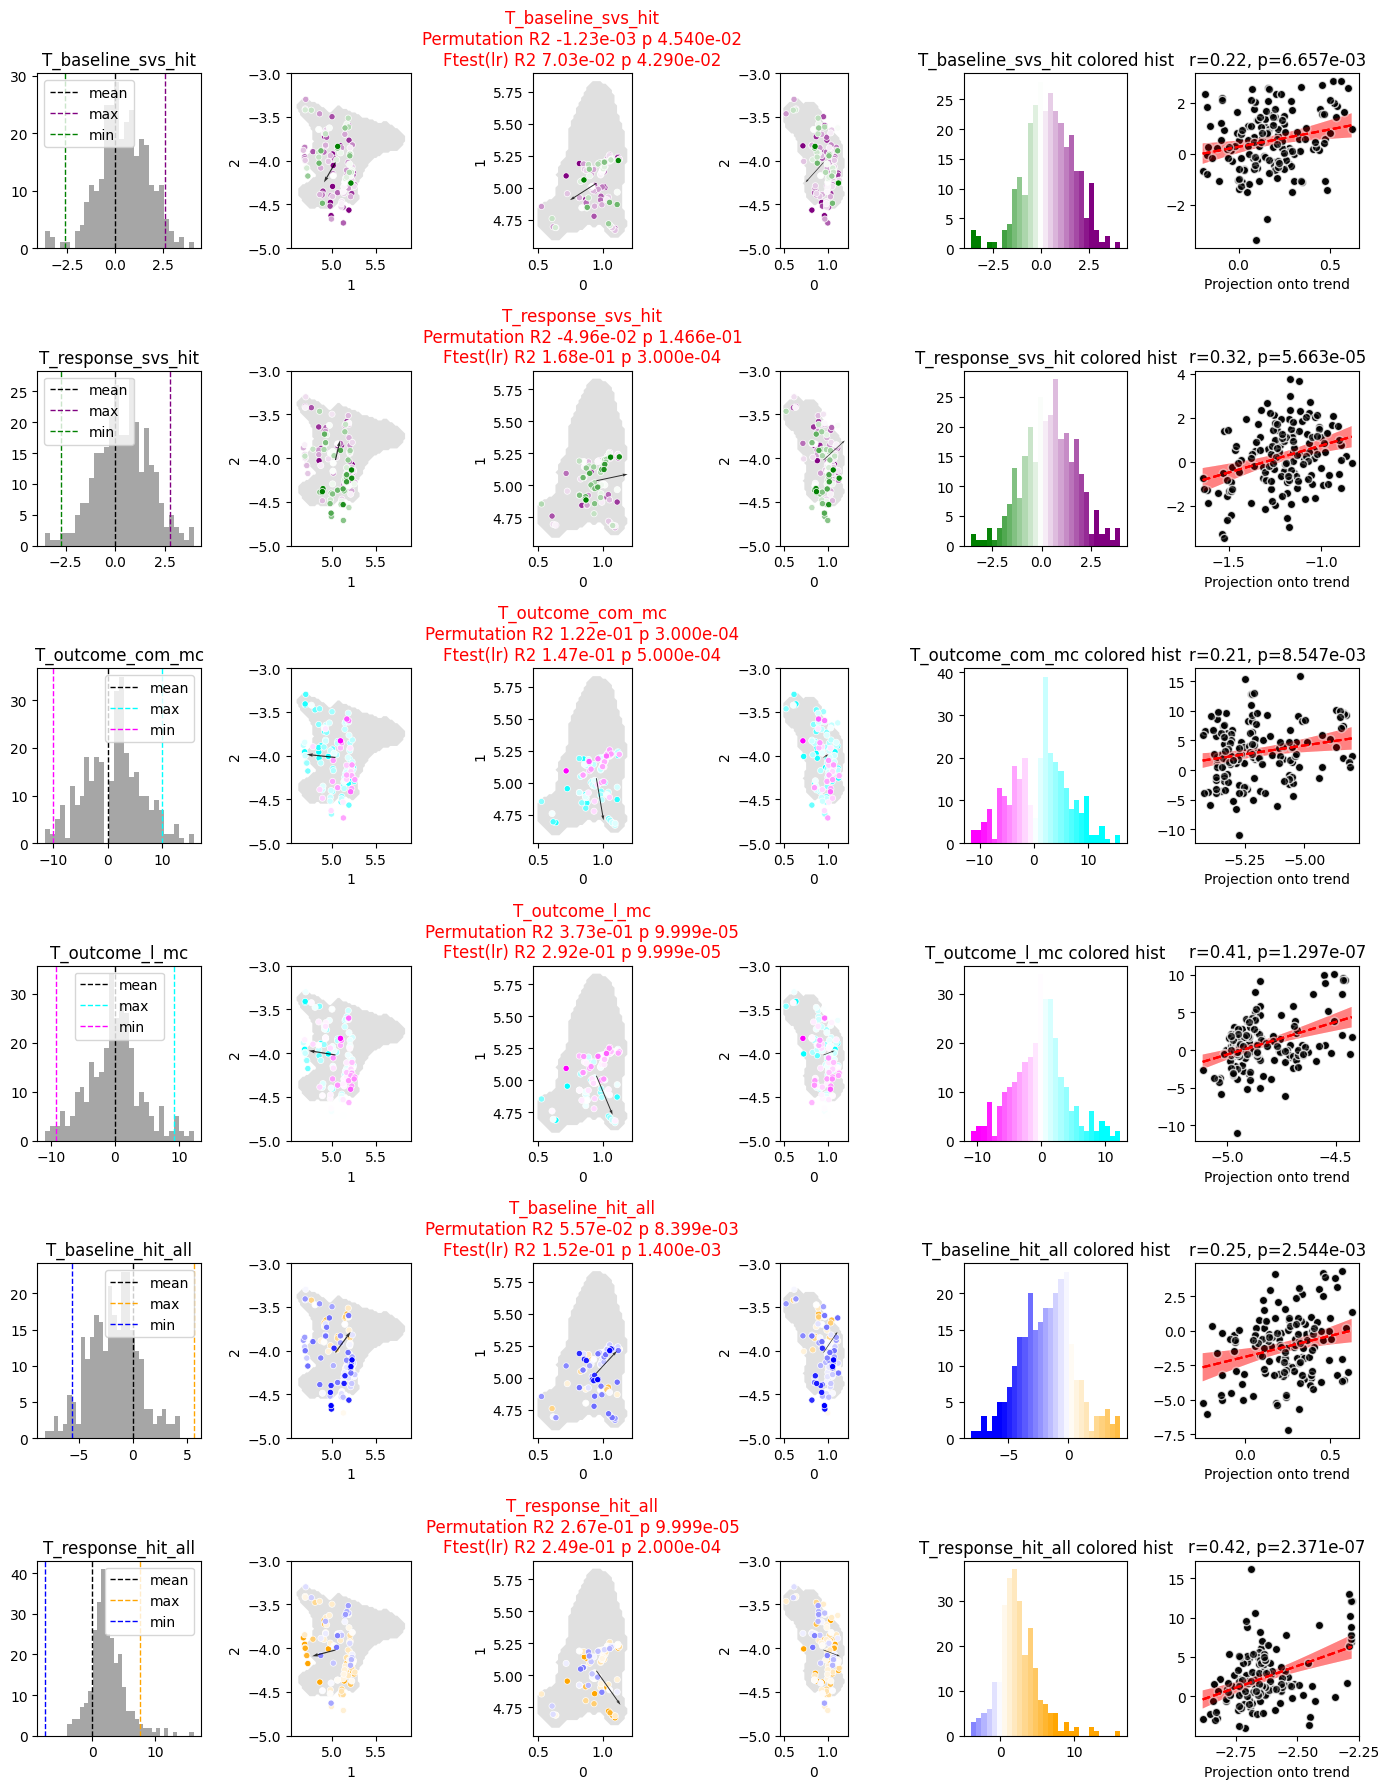

In [40]:
mask = features_combined['selected'].values > 0

fig, axes = plt.subplots(len(feature_map.keys()), 6, figsize=(14, 3 * len(feature_map.keys())))
axes = np.atleast_2d(axes)
rng = np.random.default_rng(0)
sigma = 0.001
for ind, feature, colormap in zip(range(len(feature_map.keys())), feature_map.keys(), feature_map.values()):
    color = features_combined[feature].values.astype(float)
    color_reg = color.copy()

    # === Normalize colors to 0–1 ===
    amp_cut = np.nanquantile(np.abs(color_reg), 0.95)
    color_reg = 0.5 + 0.5 * color_reg / amp_cut
    color_reg = np.clip(color_reg, 0, 1)
    center_line = 0
    upper_limit = amp_cut
    lower_limit = -amp_cut

    # color_reg[np.isnan(color_reg)] = 0.5

    # === Histogram of feature values ===
    ax_hist = axes[ind, 0]
    ax_hist.hist(features_combined[feature].values, bins=30, color='gray', alpha=0.7)
    ax_hist.set_title(feature)
    ax_hist.axvline(center_line, color='k', linestyle='--', linewidth=1, label='mean')
    ax_hist.axvline(upper_limit, color=colormap(1.0), linestyle='--', linewidth=1, label = 'max')
    ax_hist.axvline(lower_limit, color=colormap(0.0), linestyle='--', linewidth=1, label = 'min')
    ax_hist.legend()

    # === Sort and filter ===
    sort_ind = np.argsort(color_reg[mask])[::-1]
    ccfs_plot = ccfs[mask][sort_ind]
    color_reg_plot = color_reg[mask][sort_ind]
    # sorted df
    features_combined_sorted = features_combined[mask].iloc[sort_ind]

    # === Precompute RGBA facecolors ===
    rgba_colors = colormap(color_reg_plot)
    rgba_colors[:, -1] = 1  # fixed alpha

    # === 2D plane projections ===
    for plane, ax in zip(planes.keys(), axes[ind, 1:]):
        # background mesh outline
        # ax.scatter(
        #     mesh_vertices_mm[:, planes[plane][0]],
        #     mesh_vertices_mm[:, planes[plane][1]],
        #     color='k', alpha=0.4, s=0.05, edgecolors='none'
        # )
        for c in mesh_contours[plane]:
            ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.7, linewidth=0)
        # mesh = ax.scatter(mesh_vertices_mm[:, planes[plane][0]], mesh_vertices_mm[:, planes[plane][1]], s=0.1, color='black', edgecolor = 'none', alpha=0.3)
        # scatter the points (alpha-scaled)

        sc = ax.scatter(
            ccfs_plot[:, planes[plane][0]][~np.isnan(color_reg_plot)],
            ccfs_plot[:, planes[plane][1]][~np.isnan(color_reg_plot)],
            facecolors=rgba_colors[~np.isnan(color_reg_plot)],
            edgecolors=[1, 1, 1],
            s=20,
            linewidths=0.5,
        )

        # add estimated arrow from linear trend
        coef = spatial_dependence_results[feature]['linear_trend']['coef_const_x_y_z']
        arrow_start = np.nanmean(ccfs, axis=0)
        arrow_vec = np.array([coef[1], coef[2], coef[3]])/np.linalg.norm([coef[1], coef[2], coef[3]])
        ax.quiver(
            arrow_start[planes[plane][0]],
            arrow_start[planes[plane][1]],
            arrow_vec[planes[plane][0]],
            arrow_vec[planes[plane][1]],
            angles='xy', scale_units='xy', scale=3,
            color='k', width=0.01, alpha=0.8
        )

        if plane == 'hor':
            if spatial_dependence_results[feature]['cv_predictability_knn']['p_value_permutation']<0.05 or spatial_dependence_results[feature]['linear_trend']['p_value_permutation_r2']<0.05:
                title_color = 'red'
            else:
                title_color = 'black'
            ax.set_title(
                f"{feature}\n"
                f"Permutation R2 {spatial_dependence_results[feature]['cv_predictability_knn']['r2_cv']:.2e} p {spatial_dependence_results[feature]['cv_predictability_knn']['p_value_permutation']:.3e}\n"
                f"Ftest(lr) R2 {spatial_dependence_results[feature]['linear_trend']['r2']:.2e} p {spatial_dependence_results[feature]['linear_trend']['p_value_permutation_r2']:.3e}",
                color=title_color
            )
        

        ax.set_xlabel(planes[plane][0])
        ax.set_ylabel(planes[plane][1])
        ax.set_aspect('equal')

        if planes[plane][1] == dv:
            ax.set_ylim([-5, -3])
        
        ax_hist_color = axes[ind, -2]
        # make colored histogram with each bin colored according to the colormap
        edges = np.linspace(np.nanmin(features_combined[feature].values), np.nanmax(features_combined[feature].values), 30)
        # colors and counts of each bin
        bin_centers = 0.5 * (edges[:-1] + edges[1:])
        bin_colors = colormap(0.5 + 0.5 * bin_centers / amp_cut)
        bin_colors = np.clip(bin_colors, 0, 1)
        counts = np.histogram(features_combined[feature].values, bins=edges)[0]
        for i in range(len(edges) - 1):
            ax_hist_color.bar(bin_centers[i], counts[i], width=edges[1] - edges[0], color=bin_colors[i], alpha=1)
        ax_hist_color.set_title(f'{feature} colored hist')

        ax_scatter = axes[ind, -1]
        # project to primary axis
        ccf_proj = ccfs @ arrow_vec
        ax_scatter.scatter(ccf_proj, color, alpha=0.7, edgecolors='white', color = 'k')
        ax_scatter.set_xlabel('Projection onto trend')
        # plot linear fit for visualization
        valid_mask = ~np.isnan(color) & ~np.isnan(ccf_proj)
        
        
        if np.sum(valid_mask) > 1:
            # correlation and p-value
            r, p = stats.pearsonr(ccf_proj[valid_mask], color[valid_mask])
            # Prepare data
            X = ccf_proj[valid_mask].reshape(-1, 1)
            y = color[valid_mask]

            # Fit model
            reg = LinearRegression().fit(X, y)

            # Prediction grid
            x_fit = np.linspace(np.nanmin(ccf_proj), np.nanmax(ccf_proj), 100)
            X_fit = x_fit.reshape(-1, 1)
            y_fit = reg.predict(X_fit)

            # --- Compute confidence interval ---
            n = len(X)
            x_mean = np.mean(X)
            Sxx = np.sum((X - x_mean)**2)

            # residuals
            y_pred = reg.predict(X)
            residuals = y - y_pred
            s_err = np.sqrt(np.sum(residuals**2) / (n - 2))

            # t critical value
            t_val = stats.t.ppf(0.975, df=n-2)

            # standard error of prediction mean
            conf = t_val * s_err * np.sqrt(
                1/n + (x_fit - x_mean)**2 / Sxx
            )

            # --- Plot ---
            ax_scatter.plot(x_fit, y_fit, 'r--')
            ax_scatter.fill_between(
                x_fit,
                y_fit - conf,
                y_fit + conf,
                color='red',
                alpha=0.2,
                edgecolor='none'
            )

            ax_scatter.set_title(f'r={r:.2f}, p={p:.3e}')

            # # add shade area for confidence interval
            # from sklearn.utils import resample
            # n_bootstraps = 1000
            # bootstrapped_scores = []
            # for i in range(n_bootstraps):
            #     X_resampled, y_resampled = resample(X, y)
            #     reg_resampled = LinearRegression().fit(X_resampled, y_resampled)
            #     bootstrapped_scores.append(reg_resampled.score(X_resampled, y_resampled))
            # ci_lower = np.percentile(bootstrapped_scores, 2.5)
            # ci_upper = np.percentile(bootstrapped_scores, 97.5)
            # ax_scatter.fill_between(x_fit, y_fit - 1.96 * np.std(bootstrapped_scores), y_fit + 1.96 * np.std(bootstrapped_scores), color='red', alpha=0.2)
            



plt.tight_layout()
save_panels(fig, target_folder, f'model_combined_spatial_{criteria_name}', ['Figure5c', 'Figure5g', 'Figure6a'], exts=('pdf', 'png', 'svg'), bbox_inches='tight', dpi=300)
# ---- panel CSVs (rule 1 scatter, LC-space t-stat maps; rule 9 mapping: 5c=respond-ignore, 5g=switch-stay, 6a=reward-noreward) ----
_m54 = features_combined['selected'].values > 0
for _panel, _feat in [('Figure5c', 'T_baseline_hit_all'), ('Figure5g', 'T_response_svs_hit'), ('Figure6a', 'T_outcome_com_mc')]:
    save_panel_csv(columns_to_df(x_ccf_mm=ccfs[_m54, 0], y_ccf_mm=ccfs[_m54, 1], z_ccf_mm=ccfs[_m54, 2], **{_feat: features_combined[_feat].values[_m54]}), target_folder, f'model_combined_spatial_{criteria_name}', [_panel])
# plt.close()
##Figure5c## "T_baseline_hit_all"
##Figure5g## "T_response_svs_hit"
##Figure6a## "T_outcome_com_mc"

In [41]:
print(f'Baseline hit: {np.sum(~np.isnan(features_combined["p_baseline_hit_all"].values[mask]))}')
print(f'Response svs: {np.sum(~np.isnan(features_combined["p_response_svs_hit"].values[mask]))}')
print(f'Outcome com: {np.sum(~np.isnan(features_combined["p_outcome_com_mc"].values[mask]))}')

Baseline hit: 216
Response svs: 240
Outcome com: 241


In [42]:
print(f'Baseline hit: {np.mean(features_combined["p_baseline_hit_all"].values[mask] < 0.05)}')
print(f'Response svs: {np.mean(features_combined["p_response_svs_hit"].values[mask] < 0.05)}')
print(f'Outcome combined: {np.mean(features_combined["p_outcome_com_mc"].values[mask] < 0.05)}')

Baseline hit: 0.46473029045643155
Response svs: 0.16597510373443983
Outcome combined: 0.7676348547717843


## Statistical Correction and Feature Relationships

Apply false discovery rate (FDR) correction for multiple comparisons across the many units tested. This section also examines relationships between different neural features and behavioral encoding properties.

## Antidromic cells

In [43]:
def mww_statistic(a, b):
    from scipy.stats import rankdata
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    a = np.mod(a, 2*np.pi); b = np.mod(b, 2*np.pi)
    n1, n2 = len(a), len(b)
    pooled = np.concatenate([a, b])
    n = len(pooled)
    r = rankdata(pooled, method="average")  # 1..n
    r1, r2 = r[:n1], r[n1:]
    ang1 = 2*np.pi * r1 / n
    ang2 = 2*np.pi * r2 / n
    C1, S1 = np.cos(ang1).sum(), np.sin(ang1).sum()
    C2, S2 = np.cos(ang2).sum(), np.sin(ang2).sum()
    W = (2.0 / n) * ((C1**2 + S1**2)/n1 + (C2**2 + S2**2)/n2)
    return W

def mardia_watson_wheeler_perm(a, b, permutations=5000, seed=0):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    a = np.mod(a, 2*np.pi); b = np.mod(b, 2*np.pi)
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan, np.nan

    W_obs = mww_statistic(a, b)

    pooled = np.concatenate([a, b])
    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(permutations):
        perm = rng.permutation(pooled)
        Wp = mww_statistic(perm[:n1], perm[n1:])
        count += (Wp >= W_obs)
    p = (count + 1) / (permutations + 1)
    return float(W_obs), float(p)

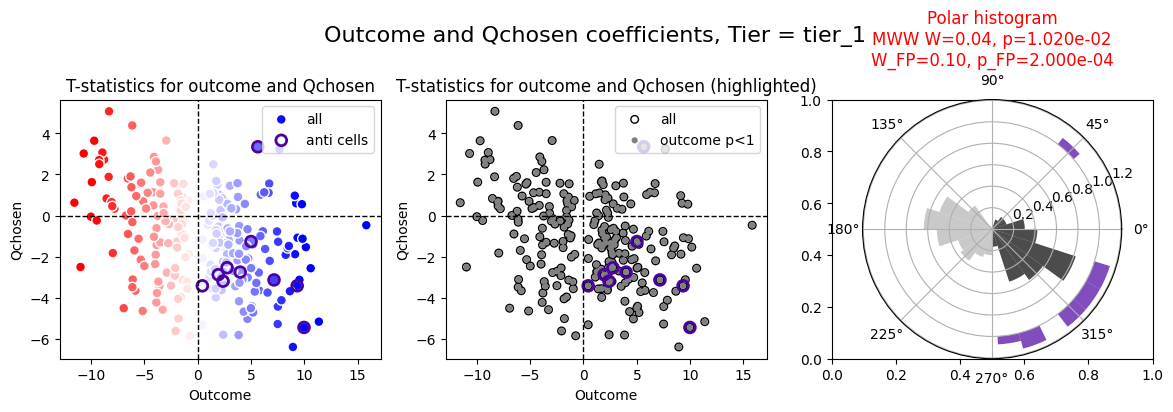

In [44]:
from scipy.stats import gaussian_kde


period = 'com'
verion = 'mc'  # 'ori' or 'mc'
c_or_t = 'T'
color_code = 'T_outcome_com_mc'
tier = 'tier_1'
thresh = 1

# --- filtering ---
# filter = np.array(features_combined['be_filter'].values, dtype=bool)
# filter = np.full(len(features_combined), True)
# filter = filter & (features_combined['bl_mean'].values >= 2)
filter = features_combined['selected'].values

# --- coefficients and stats ---
curr_coefs_outcome = features_combined[f'coef_outcome_{period}_{verion}'].values[filter]
curr_coefs_q = features_combined[f'coef_Qchosen_{period}_{verion}'].values[filter]
curr_T_outcome = features_combined[f'T_outcome_{period}_{verion}'].values[filter]
curr_T_q = features_combined[f'T_Qchosen_{period}_{verion}'].values[filter]
curr_p_outcome = features_combined[f'p_outcome_{period}_{verion}'].values[filter]

# --- figure setup ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
outcome_T_all, qchosen_T_all = curr_T_outcome, curr_T_q
outcome_coef_all, qchosen_coef_all = curr_coefs_outcome, curr_coefs_q
outcome_P_all = curr_p_outcome

color_reg = features_combined[color_code].values[filter]
amp_cut = np.nanquantile(np.abs(color_reg), 0.95)
color_reg = 0.5 + 0.5 * color_reg / amp_cut
color_reg = np.clip(color_reg, 0, 1)
center_line = 0
upper_limit = amp_cut
lower_limit = -amp_cut
# color_reg[~np.isnan(color_reg)] = rankdata(color_reg[~np.isnan(color_reg)]) / len(color_reg[~np.isnan(color_reg)])
# === Colormap ===
custom_cmap = LinearSegmentedColormap.from_list(
    'blue_white_red', [(0.0, 'red'), (0.5, 'white'), (1.0, 'blue')]
)


# === Scatter of T-values ===
axes[0].scatter(outcome_T_all, qchosen_T_all, c = color_reg, edgecolors=[1, 1, 1], cmap = custom_cmap, s=50, label='all')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Qchosen')
axes[0].set_title('T-statistics for outcome and Qchosen')
axes[0].axhline(0, color='k', linestyle='--', linewidth=1)
axes[0].axvline(0, color='k', linestyle='--', linewidth=1)
axes[0].legend()

axes[1].scatter(outcome_T_all, qchosen_T_all, color='none', edgecolors='k', s=30, label='all')
axes[1].scatter(outcome_T_all[outcome_P_all < thresh], qchosen_T_all[outcome_P_all < thresh], color='gray', edgecolors='none', s=20, label=f'outcome p<{thresh}')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Qchosen')
axes[1].set_title('T-statistics for outcome and Qchosen (highlighted)')
axes[1].axhline(0, color='k', linestyle='--', linewidth=1)
axes[1].axvline(0, color='k', linestyle='--', linewidth=1)
axes[1].legend()

# === Polar histogram (main background) ===
edges = np.linspace(-np.pi, np.pi, 4 * 5 + 1)
axes[2] = fig.add_subplot(133, polar=True)
all_vec = np.column_stack((
    outcome_coef_all,
    qchosen_coef_all
))
cat_mask = outcome_coef_all > 0

# positive (gray)
theta_pos = np.arctan2(all_vec[~cat_mask, 1], all_vec[~cat_mask, 0])
axes[2].hist(theta_pos, bins=edges, color=[0.7, 0.7, 0.7],
             alpha=0.7, edgecolor='none', density=True)
# negative (black)
theta_neg = np.arctan2(all_vec[cat_mask, 1], all_vec[cat_mask, 0])
axes[2].hist(theta_neg, bins=edges, color=[0, 0, 0],
             alpha=0.7, edgecolor='none', density=True)

# axes[1].set_yticks([])
axes[2].set_title('Polar histogram')

# === Antidromic data (for outer circular histogram) ===
mask = (features_combined[tier].astype(bool)) & filter
curr_coefs_outcome_anti = features_combined[f'coef_outcome_{period}_{verion}'].values[mask]
curr_coefs_q_anti = features_combined[f'coef_Qchosen_{period}_{verion}'].values[mask]
curr_T_outcome_anti = features_combined[f'T_outcome_{period}_{verion}'].values[mask]
curr_T_q_anti = features_combined[f'T_Qchosen_{period}_{verion}'].values[mask]

new_vec_anti = np.column_stack((curr_coefs_outcome_anti, curr_coefs_q_anti))
theta_anti = np.arctan2(new_vec_anti[:, 1], new_vec_anti[:, 0])

# --- add circular histogram around the edge ---
num_bins = 31
counts, bin_edges = np.histogram(theta_anti, bins=num_bins, range=(-np.pi, np.pi), density=False)
counts = counts / counts.max()  # normalize for visualization

color_anti = np.array([76/255, 2/255, 161/255])
r_base = 1.0  # radius of outer circle
r_height = 0.15  # height of histogram bars

# plot bars as radial rectangles
for i in range(num_bins):
    theta_start = bin_edges[i]
    theta_end = bin_edges[i + 1]
    theta_center = 0.5 * (theta_start + theta_end)
    width = theta_end - theta_start
    height = r_height * counts[i]
    axes[2].bar(theta_center, height, width=width,
                bottom=r_base, color=color_anti, alpha=0.7, edgecolor='none', linewidth=0)
theta = np.arctan2(all_vec[:, 1], all_vec[:, 0])
identical_mask = np.isin(theta, theta_anti)
# permuation test
w, p = mardia_watson_wheeler_perm(theta[~identical_mask], theta_anti, permutations=5000, seed=0)
# kuiper test

# overlay antidromic scatter on T–T plot
axes[0].scatter(curr_T_outcome_anti, curr_T_q_anti,
                edgecolors=color_anti, facecolor='none', s=60, label='anti cells', linewidth=2)
axes[1].scatter(curr_T_outcome_anti, curr_T_q_anti,
                edgecolors=color_anti, facecolor='none', s=60, label='anti cells', linewidth=2)
plt.suptitle(f'Outcome and Qchosen coefficients, Tier = {tier}', fontsize=16)
axes[0].legend()
plt.tight_layout()

save_panels(fig, target_folder, f'scatter&polar_outcome_Qchosen_coeffs_{criteria_name}_with_anti_at_{tier}_p<{thresh}', ['Figure6e', 'Figure6f'], exts=('pdf', 'svg'), bbox_inches='tight')

# ---- panel CSVs (rule 9: Figure6e=scatter, Figure6f=polar histogram) ----
_nm = f'scatter&polar_outcome_Qchosen_coeffs_{criteria_name}_with_anti_at_{tier}_p<{thresh}'
save_panel_csv(columns_to_df(T_outcome=outcome_T_all, T_qchosen=qchosen_T_all), target_folder, _nm, ['Figure6e'], plot_type='scatter')
save_panel_csv(columns_to_df(theta_rad=np.arctan2(qchosen_coef_all, outcome_coef_all), rho=np.hypot(outcome_coef_all, qchosen_coef_all)), target_folder, _nm, ['Figure6f'], plot_type='polar_histogram')


FP_outcome_file = os.path.join(capsule_dirs['manuscript_fig_dir'], 'F_photometry', 'compare_params', 'glm_coeff_theta_start_0.7.csv')
outcome_theta = pd.read_csv(FP_outcome_file)
theta_FP = outcome_theta.values
w_FP, p_FP = mardia_watson_wheeler_perm(theta, theta_FP, permutations=5000, seed=0)
axes[2].set_title(f'Polar histogram\nMWW W={w:.2f}, p={p:.3e}\nW_FP={w_FP:.2f}, p_FP={p_FP:.3e}', color='red' if p < 0.05 else 'black')

plt.show()

##Figure6e##
##Figure6f##

In [45]:
results_tier1_vs_untier1 = {}
for feature in feature_map.keys():
    result = welch_shift_P_vs_U(
        features_combined[feature].values[filter],
        features_combined['tier_1'].astype(bool).values[filter],
        alternative="two-sided",
        permutations=5000,
        seed=0,
    )

    result_z = binary_shift_P_vs_U(
        (features_combined[feature].values[filter] > 0).astype(int),
        features_combined['tier_1'].astype(bool).values[filter],
        alternative="two-sided",
        permutations=5000,
        seed=0,
    )

    results_tier1_vs_untier1[feature] = {
        "welch_shift": result,
        "binary_shift": result_z,
    }

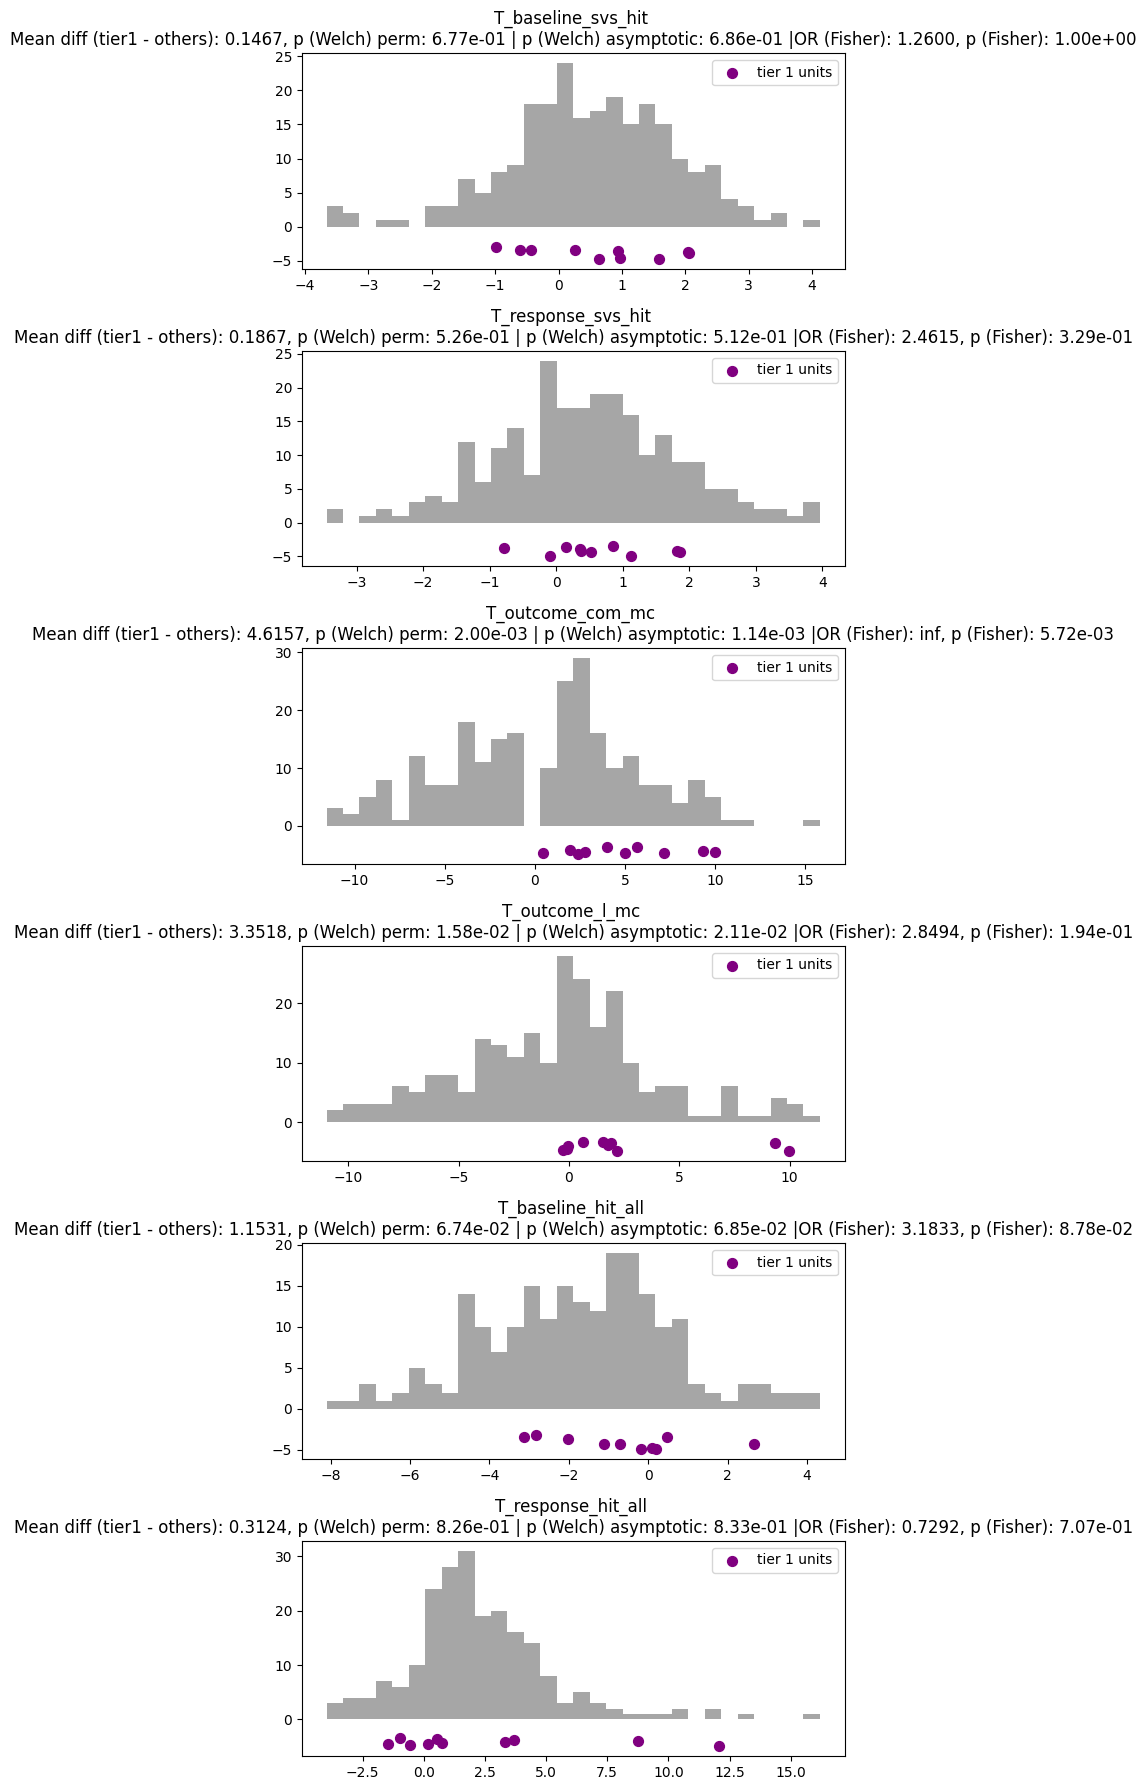

In [46]:
# histogram of all other features with dots of antidromic tier1 units on top
# filter = np.array(features_combined['be_filter'].values, dtype=bool)
# filter = filter & (features_combined['bl_mean'].values >= 2)
# filter = filter & (~features_combined['sd'].isnull())

filter = features_combined['selected'].values
fig, axes = plt.subplots(len(feature_map.keys()), 1, figsize=(6, 3 * len(feature_map.keys())))
for ind, feature in enumerate(feature_map.keys()):
    ax_hist = axes[ind]
    ax_hist.hist(features_combined[feature].values[filter], bins=30, color='gray', alpha=0.7)
    ax_hist.set_title(feature)

    # antidromic tier 1 units
    tier1_units = features_combined[features_combined['tier_1'].astype(bool) & filter][feature].values
    ax_hist.scatter(tier1_units, np.zeros_like(tier1_units)-5 + np.random.rand(len(tier1_units))*2, color='purple', s=50, label='tier 1 units', zorder=5)
    ax_hist.legend()

    ax_hist.set_title(
        f"{feature} \n"
        f"Mean diff (tier1 - others): {results_tier1_vs_untier1[feature]['welch_shift']['mean_diff_P_minus_U']:.4f}, "
        f"p (Welch) perm: {results_tier1_vs_untier1[feature]['welch_shift']['p_value_permutation']:.2e} | "
        f"p (Welch) asymptotic: {results_tier1_vs_untier1[feature]['welch_shift']['p_value_asymptotic']:.2e} |"
        f"OR (Fisher): {results_tier1_vs_untier1[feature]['binary_shift']['odds_ratio_fisher']:.4f}, "
        f"p (Fisher): {results_tier1_vs_untier1[feature]['binary_shift']['p_value_fisher']:.2e}"
    )
# increase spacing
plt.subplots_adjust(hspace=0.5)
plt.tight_layout()
# save
save_panels(fig, target_folder, f'histograms_features_with_tier1_dots_{criteria_name}', ['Figure5k_right', 'FigureS17i_right'], exts=('pdf',), bbox_inches='tight')
# ---- panel CSVs (rule 8 histogram, all + tier1; map: Figure5k_right=T_response_svs_hit, FigureS17i_right=T_baseline_hit_all) ----
_flt = features_combined['selected'].values
_t1 = (features_combined['tier_1'].astype(bool)) & _flt
for _p, _feat in [('Figure5k_right', 'T_response_svs_hit'), ('FigureS17i_right', 'T_baseline_hit_all')]:
    save_panel_csv(columns_to_df(**{f'{_feat}_all': features_combined[_feat].values[_flt], f'{_feat}_tier1': features_combined[_feat].values[_t1]}), target_folder, f'histograms_features_with_tier1_dots_{criteria_name}', [_p])
##Figure5k_right## "T_response_svs_hit"
##FigureS17i_right## "T_baseline_hit_all"

In [47]:
from pycircstat2.hypothesis import rayleigh_test
import numpy as np

theta = np.asarray(theta).ravel()  # radians

res = rayleigh_test(theta)

print(res)
print("Rayleigh z:", res.z)
print("p-value:", res.pval)

RayleighTestResult(r=np.float64(0.2846520351522596), z=np.float64(19.5274542490339), pval=np.float64(2.285130019247873e-09), bootstrap_pval=None)
Rayleigh z: 19.5274542490339
p-value: 2.285130019247873e-09


## Comparison with Photometry Data

Compare single-unit encoding with population-level signals measured by fiber photometry. This analysis determines whether single neurons and bulk fluorescence show similar or complementary tuning to behavioral variables.

In [48]:
# photometry data load
FP_path = os.path.join(capsule_dirs['manuscript_fig_dir'], 'F_photometry', 'compare_params', 'scatter_data_hit_svs.csv')
FP_data = pd.read_csv(FP_path)

In [49]:
# results_tier1_vs_untier1 = {}
# for feature in feature_map.keys():
#     result = welch_shift_P_vs_U(
#         features_combined[feature].values[filter],
#         features_combined['tier_1'].astype(bool).values[filter],
#         alternative="two-sided",
#         permutations=20000,
#         seed=0,
#     )

#     result_z = binary_shift_P_vs_U(
#         (features_combined[feature].values[filter] > 0).astype(int),
#         features_combined['tier_1'].astype(bool).values[filter],
#         alternative="two-sided",
#         permutations=20000,
#         seed=0,
#     )

#     results_tier1_vs_untier1[feature] = {
#         "welch_shift": result,
#         "binary_shift": result_z,
#     }

['/root/capsule/scratch/results/manuscript/figures/F_ephys_beh_action&outcome/FigureS17i_left_comparison_photometry_units_histograms_beh_all.csv']

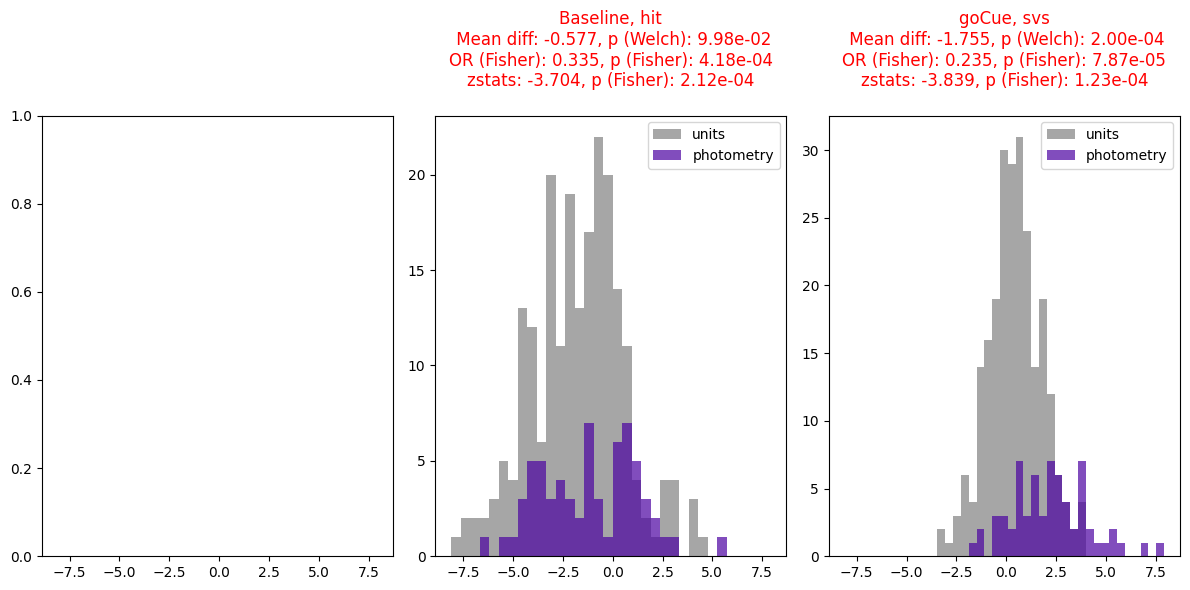

In [50]:
# check if each modality is from same or different distribution, FP vs units (same as comparing antidromic cells)
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharex=True)
filter = features_combined['selected'].values
# ax = axes[0]
# unit_values = features_combined['T_response_hit_all'].values[filter]
# FP_values = FP_data['tstats_hit_response'].values
# edges = np.linspace(np.nanmin(np.concatenate([unit_values, FP_values])), np.nanmax(np.concatenate([unit_values, FP_values])), 30)
# ax.hist(unit_values, bins=edges, color='gray', alpha=0.7, label='units')
# ax.hist(FP_values, bins=edges, color=color_anti, alpha=0.7, label='photometry')
# ax.legend()
# result = welch_shift_X_vs_Y(
#     unit_values,
#     FP_values,
#     alternative="two-sided",
#     permutations=5000,
#     seed=0,
# )

# result_z = binary_shift_X_vs_Y(
#     (unit_values > 0).astype(int),
#     (FP_values > 0).astype(int),
#     alternative="two-sided",
#     permutations=5000,
#     seed=0,
# )
# ax.set_title(
#     f'goCue, hit\n '
#     f'Mean diff: {result["mean_diff_X_minus_Y"]:.3f}, p (Welch): {result["p_value_permutation"]:.2e}\n'
#     f'OR (Fisher): {result_z["odds_ratio_fisher"]:.3f}, p (Fisher): {result_z["p_value_fisher"]:.2e}\n'
#     f'zstats: {result_z["z_stat"]:.3f}, p (Fisher): {result_z["p_value_ztest"]:.2e}\n',
#     color='red' if result["p_value_permutation"] < 0.05 or result_z["p_value_fisher"] < 0.05 else 'black'
# )

ax = axes[1]
unit_values = features_combined['T_baseline_hit_all'].values[filter]
FP_values = FP_data['tstats_hit'].values
edges = np.linspace(np.nanmin(np.concatenate([unit_values, FP_values])), np.nanmax(np.concatenate([unit_values, FP_values])), 30)
ax.hist(unit_values, bins=edges, color='gray', alpha=0.7, label='units')
ax.hist(FP_values, bins=edges, color=color_anti, alpha=0.7, label='photometry')
ax.legend()
result = welch_shift_X_vs_Y(
    unit_values,
    FP_values,
    alternative="two-sided",
    permutations=5000,
    seed=0,
)
result_z = binary_shift_X_vs_Y(
    (unit_values > 0).astype(int),
    (FP_values > 0).astype(int),
    alternative="two-sided",
    permutations=5000,
    seed=0,
)
ax.set_title(
    f'Baseline, hit\n '
    f'Mean diff: {result["mean_diff_X_minus_Y"]:.3f}, p (Welch): {result["p_value_permutation"]:.2e}\n'
    f'OR (Fisher): {result_z["odds_ratio_fisher"]:.3f}, p (Fisher): {result_z["p_value_fisher"]:.2e}\n'
    f'zstats: {result_z["z_stat"]:.3f}, p (Fisher): {result_z["p_value_ztest"]:.2e}\n',
    color='red' if result["p_value_permutation"] < 0.05 or result_z["p_value_fisher"] < 0.05 else 'black'
)

ax = axes[2]
unit_values = features_combined['T_response_svs_hit'].values[filter]
FP_values = FP_data['tstats_svs'].values
edges = np.linspace(np.nanmin(np.concatenate([unit_values, FP_values])), np.nanmax(np.concatenate([unit_values, FP_values])), 30)
ax.hist(unit_values, bins=edges, color='gray', alpha=0.7, label='units')
ax.hist(FP_values, bins=edges, color=color_anti, alpha=0.7, label='photometry')
ax.legend()
result = welch_shift_X_vs_Y(
    unit_values,
    FP_values,
    alternative="two-sided",
    permutations=5000,
    seed=0,
)
result_z = binary_shift_X_vs_Y(
    (unit_values > 0).astype(int),
    (FP_values > 0).astype(int),
    alternative="two-sided",
    permutations=5000,
    seed=0,
)
ax.set_title(
    f'goCue, svs\n '
    f'Mean diff: {result["mean_diff_X_minus_Y"]:.3f}, p (Welch): {result["p_value_permutation"]:.2e}\n'
    f'OR (Fisher): {result_z["odds_ratio_fisher"]:.3f}, p (Fisher): {result_z["p_value_fisher"]:.2e}\n'
    f'zstats: {result_z["z_stat"]:.3f}, p (Fisher): {result_z["p_value_ztest"]:.2e}\n',
    color='red' if result["p_value_permutation"] < 0.05 or result_z["p_value_fisher"] < 0.05 else 'black'
)
plt.tight_layout()
save_panels(fig, target_folder, f'comparison_photometry_units_histograms_{criteria_name}', ['Figure5k_left', 'FigureS17i_left'], exts=('pdf',), bbox_inches='tight')
_flt = features_combined['selected'].values
save_panel_csv(columns_to_df(svs_units=features_combined['T_response_svs_hit'].values[_flt], svs_photometry=FP_data['tstats_svs'].values), target_folder, f'comparison_photometry_units_histograms_{criteria_name}', ['Figure5k_left'])
save_panel_csv(columns_to_df(hit_units=features_combined['T_baseline_hit_all'].values[_flt], hit_photometry=FP_data['tstats_hit'].values), target_folder, f'comparison_photometry_units_histograms_{criteria_name}', ['FigureS17i_left'])
##Figure5k_left## "T_response_svs_hit"
##FigureS17i_left## "T_baseline_hit_all"

['/root/capsule/scratch/results/manuscript/figures/F_ephys_beh_action&outcome/FigureS15f_bottom_scatter_bl_response_corr_short_vs_T_baseline_hit_all_colored_by_bl_response_corr_short_beh_all.csv']

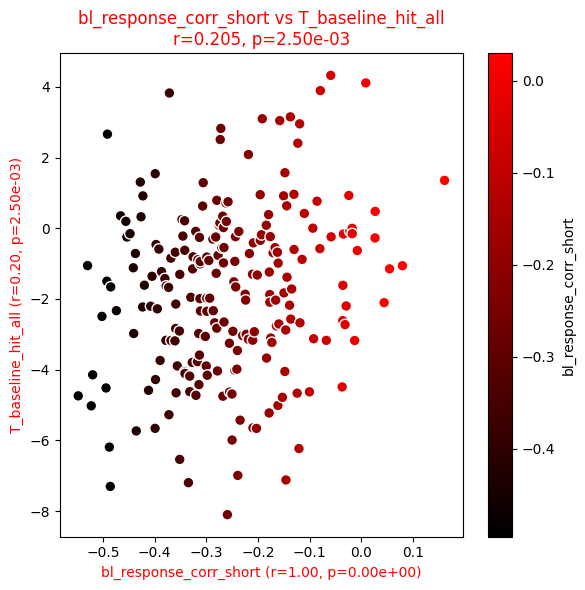

In [51]:
color_code = 'bl_response_corr_short'
x_val = 'bl_response_corr_short'
y_val = 'T_baseline_hit_all'

colormap = LinearSegmentedColormap.from_list(
    'black_red', [(0.0, 'black'), (1.0, 'red')])

fig = plt.figure(figsize=(6, 6))
curr_filter = features_combined['selected'].values


x_data = features_combined[x_val].to_numpy()[curr_filter]
y_data = features_combined[y_val].to_numpy()[curr_filter]
c_data = features_combined[color_code].to_numpy()[curr_filter]

# Sort by color (then shuffle to reduce overplot bias)
sort_ind = np.argsort(c_data)

# sort_ind = np.random.permutation(sort_ind)

sc = plt.scatter(
    x_data[sort_ind],
    y_data[sort_ind],
    alpha=1,
    edgecolors='w',
    c=c_data[sort_ind],
    cmap=colormap,
    s=60,
    vmin=np.nanquantile(c_data, 0.02),
    vmax=np.nanquantile(c_data, 0.98)
)

plt.colorbar(sc, label=color_code)

# Remove NaNs for correlation
mask = (
    ~np.isnan(x_data) &
    ~np.isnan(y_data) &
    ~np.isnan(c_data)
)

# Correlations
r_x, p_x = pearsonr(x_data[mask], c_data[mask])
r_y, p_y = pearsonr(y_data[mask], c_data[mask])

# Axis labeling with significance coloring
plt.xlabel(
    f'{x_val} (r={r_x:.2f}, p={p_x:.2e})',
    color='red' if p_x < 0.05 else 'black'
)

plt.ylabel(
    f'{y_val} (r={r_y:.2f}, p={p_y:.2e})',
    color='red' if p_y < 0.05 else 'black'
)


# correlation between x and y
r_xy, p_xy = pearsonr(x_data[mask], y_data[mask])
plt.title(
    f'{x_val} vs {y_val}\n'
    f'r={r_xy:.3f}, p={p_xy:.2e}',
    color='red' if p_xy < 0.05 else 'black'
)
plt.tight_layout()
save_panels(fig, target_folder, f'scatter_{x_val}_vs_{y_val}_colored_by_{color_code}_{criteria_name}', ['FigureS15f_bottom'], exts=('pdf',), bbox_inches='tight')

save_panel_csv(columns_to_df(**{x_val: x_data, y_val: y_data, f'colorcode_{color_code}': c_data}), target_folder, f'scatter_{x_val}_vs_{y_val}_colored_by_{color_code}_{criteria_name}', ['FigureS15f_bottom'])
##FigureS15f_bottom##

['/root/capsule/scratch/results/manuscript/figures/F_ephys_beh_action&outcome/FigureS15f_top_scatter_bl_response_corr_short_vs_response_diff_colored_by_bl_response_corr_short_beh_all.csv']

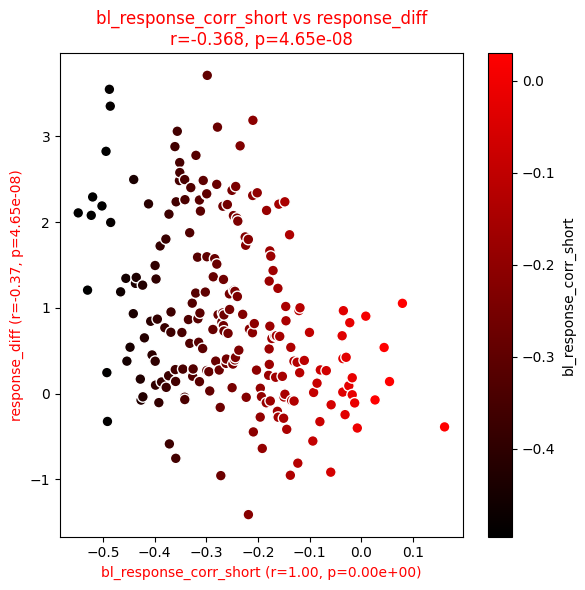

In [52]:
color_code = 'bl_response_corr_short'
x_val = 'bl_response_corr_short'
y_val = 'response_diff'

colormap = LinearSegmentedColormap.from_list(
    'black_red', [(0.0, 'black'), (1.0, 'red')])

fig = plt.figure(figsize=(6, 6))
curr_filter = features_combined['selected'].values


x_data = features_combined[x_val].to_numpy()[curr_filter]
y_data = features_combined[y_val].to_numpy()[curr_filter]
c_data = features_combined[color_code].to_numpy()[curr_filter]

# Sort by color (then shuffle to reduce overplot bias)
sort_ind = np.argsort(c_data)

# sort_ind = np.random.permutation(sort_ind)

sc = plt.scatter(
    x_data[sort_ind],
    y_data[sort_ind],
    alpha=1,
    edgecolors='w',
    c=c_data[sort_ind],
    cmap=colormap,
    s=60,
    vmin=np.nanquantile(c_data, 0.02),
    vmax=np.nanquantile(c_data, 0.98)
)

plt.colorbar(sc, label=color_code)

# Remove NaNs for correlation
mask = (
    ~np.isnan(x_data) &
    ~np.isnan(y_data) &
    ~np.isnan(c_data)
)

# Correlations
r_x, p_x = pearsonr(x_data[mask], c_data[mask])
r_y, p_y = pearsonr(y_data[mask], c_data[mask])

# Axis labeling with significance coloring
plt.xlabel(
    f'{x_val} (r={r_x:.2f}, p={p_x:.2e})',
    color='red' if p_x < 0.05 else 'black'
)

plt.ylabel(
    f'{y_val} (r={r_y:.2f}, p={p_y:.2e})',
    color='red' if p_y < 0.05 else 'black'
)


# correlation between x and y
r_xy, p_xy = pearsonr(x_data[mask], y_data[mask])
plt.title(
    f'{x_val} vs {y_val}\n'
    f'r={r_xy:.3f}, p={p_xy:.2e}',
    color='red' if p_xy < 0.05 else 'black'
)
plt.tight_layout()
save_panels(fig, target_folder, f'scatter_{x_val}_vs_{y_val}_colored_by_{color_code}_{criteria_name}', ['FigureS15f_top'], exts=('pdf',), bbox_inches='tight')

save_panel_csv(columns_to_df(**{x_val: x_data, y_val: y_data, f'colorcode_{color_code}': c_data}), target_folder, f'scatter_{x_val}_vs_{y_val}_colored_by_{color_code}_{criteria_name}', ['FigureS15f_top'])

##FigureS15f_top##


['/root/capsule/scratch/results/manuscript/figures/F_ephys_beh_action&outcome/FigureS15e_histogram_bl_response_corr_short_beh_all.csv']

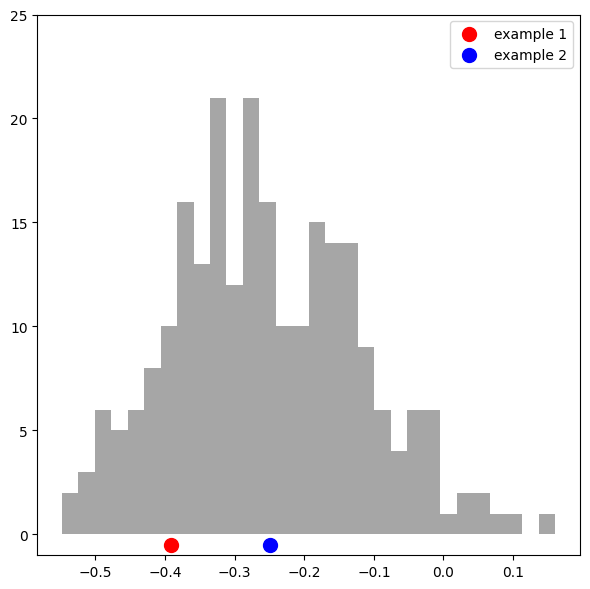

In [53]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.hist(features_combined['bl_response_corr_short'].values[features_combined['selected'].values], bins=30, color='gray', alpha=0.7);
example_1 = ['behavior_751766_2025-02-14_11-37-11', '36']
example_2 = ['behavior_751766_2025-02-11_11-53-38', '11']
# find the index of the examples
example_1_mask = (features_combined['session'] == example_1[0]) & (features_combined['unit'] == example_1[1])
example_2_mask = (features_combined['session'] == example_2[0]) & (features_combined['unit'] == example_2[1])
ax.scatter(features_combined['bl_response_corr_short'].values[example_1_mask], -0.5, color='red', s=100, label='example 1')
ax.scatter(features_combined['bl_response_corr_short'].values[example_2_mask], -0.5, color='blue', s=100, label='example 2')

ax.set_ylim(-1, 25)
ax.legend()
plt.tight_layout()
save_panels(fig, target_folder, f'histogram_bl_response_corr_short_{criteria_name}', ['FigureS15e'], exts=('pdf',), bbox_inches='tight')

# ---- panel CSV (rule 8 histogram raw values + example points) ----
_sel = features_combined['selected'].values
save_panel_csv(columns_to_df(bl_response_corr_short=features_combined['bl_response_corr_short'].values[_sel], example_1=features_combined['bl_response_corr_short'].values[example_1_mask], example_2=features_combined['bl_response_corr_short'].values[example_2_mask]), target_folder, f'histogram_bl_response_corr_short_{criteria_name}', ['FigureS15e'])
##FigureS15e##

In [54]:
## Add code here for the two examples in FigureS15d##
example_1_mask = (features_combined['session'] == example_1[0]) & (features_combined['unit'] == example_1[1])
np.sum(example_1_mask)

np.int64(1)

## Plot location of antidromic cells


In [55]:
features_combined[features_combined['tier_1'].values.astype(bool)][['session', 'unit_id']]

,session,unit_id
2018,behavior_751769_2025-01-17_11-37-39,288
2047,behavior_751769_2025-01-18_10-15-25,29
3918,behavior_751181_2025-02-26_11-51-19,39
4132,behavior_751181_2025-02-26_11-51-19,273
4176,behavior_751181_2025-02-27_11-24-47,46
4363,behavior_751181_2025-02-27_11-24-47,244
4678,behavior_754897_2025-03-13_11-20-42,49
6003,behavior_752014_2025-03-26_11-18-57,46
6287,behavior_752014_2025-03-28_11-04-59,27
8149,behavior_782394_2025-04-23_10-51-17,7


## Tuning curve and psth

In [56]:
def get_psth_tuning_curve(session, unit_id, target_var, align, num_bin, tb, tf, kernel=True, tau_rise=0.001, tau_decay = 0.08, step_size = 0.05, tuning_win = [0.2, 1.2], quantile_bins=False):
    session_df = get_session_tbl(session)
    trial_tbl = makeSessionDF(session, cut_interruptions=True, model_name='stan_qLearning_5params')
    unit_tbl = get_unit_tbl(session, data_type='curated')
    unit_drift = load_drift(session, unit_id)
    unit_row = unit_tbl[unit_tbl['unit_id'] == unit_id]
    if len(unit_row) == 0:
        unit_row = unit_tbl[unit_tbl['unit_id'] == int(unit_id)]
    spike_times = unit_row['spike_times'].values[0]
    trial_tbl_curr = trial_tbl.copy()
    spike_times_curr = spike_times.copy()
    if unit_drift is not None:
        if unit_drift['ephys_cut'][0] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr >= unit_drift['ephys_cut'][0]]
            trial_tbl_curr = trial_tbl_curr[trial_tbl_curr['go_cue_start_time'] >= unit_drift['ephys_cut'][0]]
        if unit_drift['ephys_cut'][1] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr <= unit_drift['ephys_cut'][1]]
            trial_tbl_curr = trial_tbl_curr[trial_tbl_curr['go_cue_start_time'] <= unit_drift['ephys_cut'][1]]
    align_events = trial_tbl_curr[align].values
    currArray, slide_times = get_spike_matrix(spike_times_curr, align_events, 
                                        pre_event=tb, post_event=tf, 
                                        kernel=kernel, stepSize=step_size,
                                        tau_rise=tau_rise, tau_decay=tau_decay, avoid_overlap=True)
    currArray[~np.isnan(currArray)] = zscore(currArray[~np.isnan(currArray)])
    # get mean psth
    focus_vals = trial_tbl_curr[target_var].values
    if num_bin%2 == 0 and any(focus_vals>0) and any(focus_vals<0):
        bin_edges = np.linspace(np.min(focus_vals), 0, num_bin//2 + 1).tolist() + np.linspace(0, np.max(focus_vals), num_bin//2 + 1)[1:].tolist()
    else:
        bin_edges = np.linspace(np.min(focus_vals), np.max(focus_vals), num_bin + 1)
    if quantile_bins:
        bin_edges = np.quantile(focus_vals[~np.isnan(focus_vals)], np.linspace(0, 1, num_bin + 1))
    
    psth_means = np.full((num_bin, currArray.shape[1]), np.nan)
    target_means = np.full((num_bin,), np.nan)
    neuron_means = np.full((num_bin,), np.nan)
    spike_counts_tuning = np.full((len(trial_tbl_curr),), np.nan)
    for trial_ind in range(len(trial_tbl_curr)):
        # count spikes in tuning window
        spike_counts_tuning[trial_ind] = np.sum(
            (spike_times_curr >= (align_events[trial_ind] + tuning_win[0])) &
            (spike_times_curr < (align_events[trial_ind] + tuning_win[1]))
        )/(tuning_win[1] - tuning_win[0])
    for bin_ind in range(num_bin):
        bin_mask = (focus_vals >= bin_edges[bin_ind]) & (focus_vals < bin_edges[bin_ind + 1])
        if np.sum(bin_mask) > 0:
            psth_means[bin_ind, :] = np.nanmean(currArray[bin_mask, :], axis=0)
            target_means[bin_ind] = np.mean(focus_vals[bin_mask])
            neuron_means[bin_ind] = np.nanmean(spike_counts_tuning[bin_mask])
    neuron_means[~np.isnan(neuron_means)] = zscore(neuron_means[~np.isnan(neuron_means)])

    return psth_means, slide_times, target_means, neuron_means
    

In [57]:
# # test
# session = features_combined['session'].values[0]
# unit_id = features_combined['unit_id'].values[0]
# psth_means, slide_times, target_means, neuron_means = get_psth_tuning_curve(
#     session, unit_id, target_var, align, num_bins, tb, tf,
#     # tuning_win=[outcome_win_curr-0.5*win_len, outcome_win_curr+0.5*win_len], 
#     tuning_win=[0, 2],
#     tau_rise=0.001, tau_decay = 0.08, quantile_bins=quantile_bins,
# )

In [58]:
sig_P_mask = (features_combined['T_outcome_com_mc'] > 0) & (features_combined['be_filter']) & (features_combined['selected'])
sig_N_mask = (features_combined['T_outcome_com_mc'] < 0) & (features_combined['be_filter']) & (features_combined['selected'])

target_var = 'pe'
align = 'outcome_time'
num_bins = 6
quantile_bins = False
tb = -1.5
tf = 2.5
outcome_win_tt_file = CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics/beh_all_TT/auc_windows.json'
with open(outcome_win_tt_file, 'r') as f:
    outcome_win_tt = json.load(f)
    
outcome_win_np_file = CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics/beh_all_NP/auc_windows.json'
with open(outcome_win_np_file, 'r') as f:
    outcome_win_np = json.load(f)

win_len = 1.5


In [59]:
def process_row(row):
    session = row['session']
    unit_id = row['unit_id']
    # print(f"Processing session {session}, unit {unit_id}")
    if 'ZS' in session:
        outcome_win = outcome_win_tt
    else:
        outcome_win = outcome_win_np
    if np.abs(row['T_outcome_l_mc']) > np.abs(row['T_outcome_e_mc']):
        outcome_win_curr = outcome_win['late']
    else:
        outcome_win_curr = outcome_win['early']
    
    psth_means, slide_times, target_means, neuron_means = get_psth_tuning_curve(
        session, unit_id, target_var, align, num_bins, tb, tf,
        tuning_win=[outcome_win_curr-0.5*win_len, outcome_win_curr+0.5*win_len], 
        # tuning_win=[0, 2],
        tau_rise=0.001, tau_decay = 0.08, quantile_bins=quantile_bins,
    )
    return {
        'psth_means': psth_means,
        'slide_times': slide_times,
        'target_means': target_means,
        'neuron_means': neuron_means
    }

## Tuning Curves: Behavioral Variable Encoding

Generate tuning curves showing how firing rates vary as a function of continuous behavioral variables (outcome prediction, Q-values). This provides a detailed characterization of how neurons encode these variables beyond simple selectivity tests.

In [60]:
from joblib import Parallel, delayed
results_psth_tuning_sig_P = Parallel(n_jobs=-2)(
    delayed(process_row)(row)
    for index, row in features_combined[sig_P_mask].iterrows()
)
results_psth_tuning_sig_N = Parallel(n_jobs=-2)(
    delayed(process_row)(row)
    for index, row in features_combined[sig_N_mask].iterrows()
)

In [61]:
psth_means_combined_P = np.array([res['psth_means'] for res in results_psth_tuning_sig_P])
psth_means_combined_N = np.array([res['psth_means'] for res in results_psth_tuning_sig_N])
slide_times = results_psth_tuning_sig_P[0]['slide_times']
target_means_P = results_psth_tuning_sig_P[0]['target_means']
target_means_N = results_psth_tuning_sig_N[0]['target_means']
neuron_means_combined_P = np.array([res['neuron_means'] for res in results_psth_tuning_sig_P])
neuron_means_combined_N = np.array([res['neuron_means'] for res in results_psth_tuning_sig_N])

['/root/capsule/scratch/results/manuscript/figures/F_ephys_beh_action&outcome/Figure6g_PSTH_and_tuning_curves_outcome_pe_beh_all.csv']

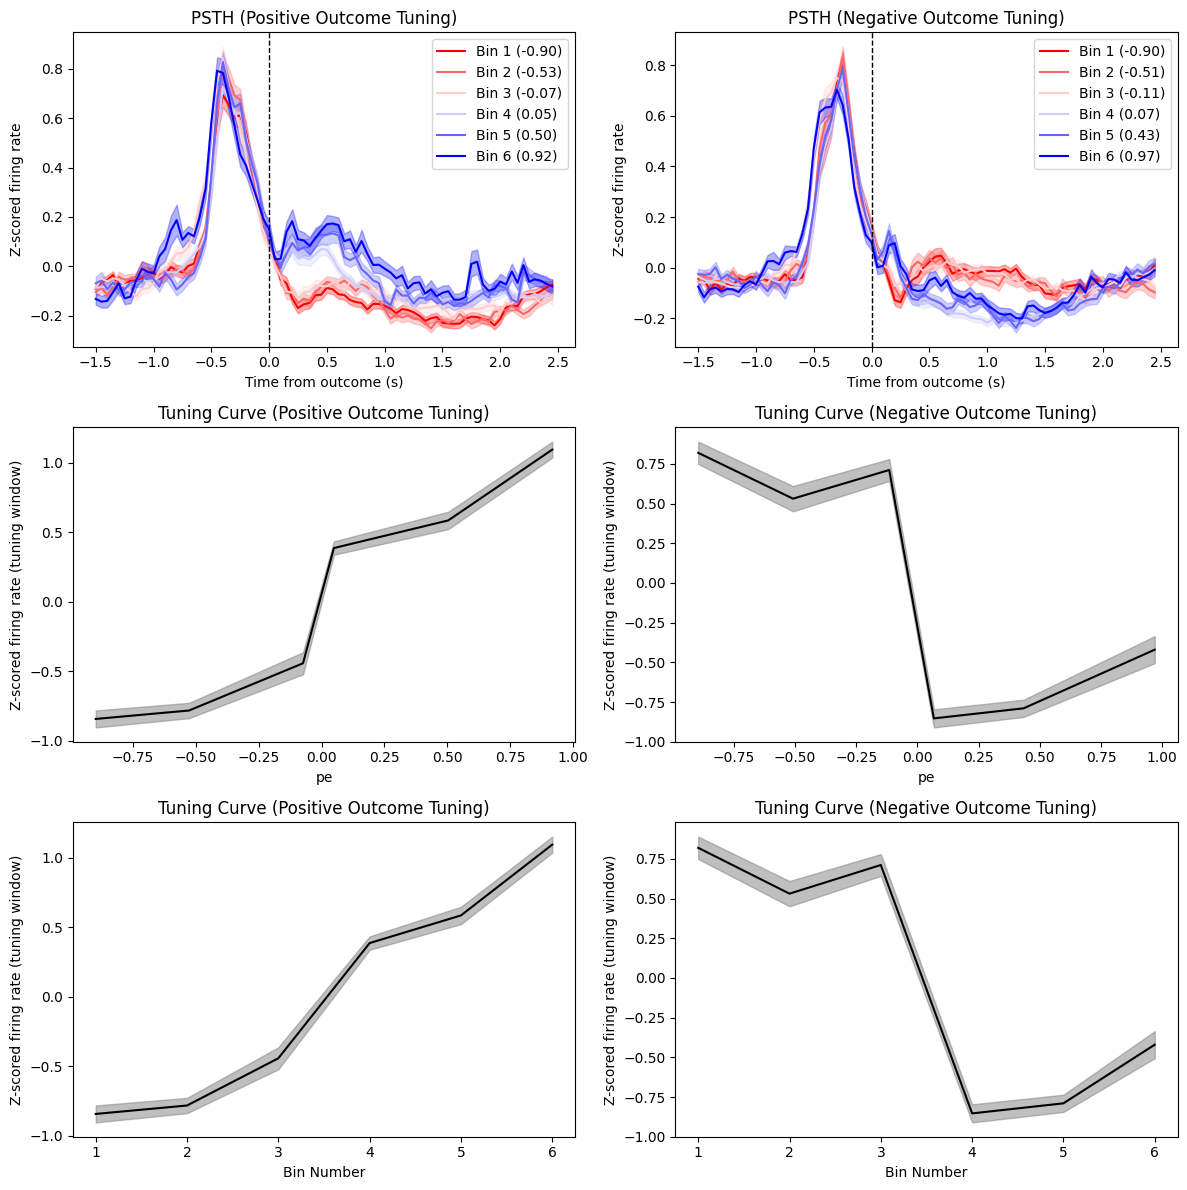

In [62]:
# custom colormap
custom_cmap = LinearSegmentedColormap.from_list(
    'red_white_blue', [(0.0, 'red'), (0.5, 'white'), (1.0, 'blue')]
)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
# plot positive tuning
ax = axes[0, 0]
for bin_ind in range(num_bins):
    ax.plot(slide_times, np.nanmean(psth_means_combined_P[:, bin_ind, :], axis=0), label=f'Bin {bin_ind+1} ({target_means_P[bin_ind]:.2f})', color=custom_cmap(bin_ind/(num_bins-1)))
    ax.fill_between(
        slide_times,
        np.nanmean(psth_means_combined_P[:, bin_ind, :], axis=0) - np.nanstd(psth_means_combined_P[:, bin_ind, :], axis=0)/np.sqrt(psth_means_combined_P.shape[0]),
        np.nanmean(psth_means_combined_P[:, bin_ind, :], axis=0) + np.nanstd(psth_means_combined_P[:, bin_ind, :], axis=0)/np.sqrt(psth_means_combined_P.shape[0]),
        color=custom_cmap(bin_ind/(num_bins-1)),
        alpha=0.3
    )
ax.set_title('PSTH (Positive Outcome Tuning)')
ax.set_xlabel('Time from outcome (s)')
ax.set_ylabel('Z-scored firing rate')
ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.legend()
# plot negative tuning
ax = axes[0, 1]
for bin_ind in range(num_bins):
    ax.plot(slide_times, np.nanmean(psth_means_combined_N[:, bin_ind, :], axis=0), label=f'Bin {bin_ind+1} ({target_means_N[bin_ind]:.2f})', color=custom_cmap(bin_ind/(num_bins-1)))
    ax.fill_between(
        slide_times,
        np.nanmean(psth_means_combined_N[:, bin_ind, :], axis=0) - np.nanstd(psth_means_combined_N[:, bin_ind, :], axis=0)/np.sqrt(psth_means_combined_N.shape[0]),
        np.nanmean(psth_means_combined_N[:, bin_ind, :], axis=0) + np.nanstd(psth_means_combined_N[:, bin_ind, :], axis=0)/np.sqrt(psth_means_combined_N.shape[0]),
        color=custom_cmap(bin_ind/(num_bins-1)),
        alpha=0.3
    )
ax.set_title('PSTH (Negative Outcome Tuning)')
ax.set_xlabel('Time from outcome (s)')
ax.set_ylabel('Z-scored firing rate')
ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.legend()
# plot tuning curves positive
ax = axes[1, 0]
ax.plot(target_means_P, np.nanmean(neuron_means_combined_P, axis=0), color='k')
ax.fill_between(
    target_means_P,
    np.nanmean(neuron_means_combined_P, axis=0) - np.nanstd(neuron_means_combined_P, axis=0)/np.sqrt(neuron_means_combined_P.shape[0]),
    np.nanmean(neuron_means_combined_P, axis=0) + np.nanstd(neuron_means_combined_P, axis=0)/np.sqrt(neuron_means_combined_P.shape[0]),
    color='gray',
    alpha=0.5
)
ax.set_title('Tuning Curve (Positive Outcome Tuning)')
ax.set_xlabel(f'{target_var}')
ax.set_ylabel('Z-scored firing rate (tuning window)')
# plot tuning curves negative
ax = axes[1, 1]
ax.plot(target_means_N, np.nanmean(neuron_means_combined_N, axis=0), color='k')
ax.fill_between(
    target_means_N,
    np.nanmean(neuron_means_combined_N, axis=0) - np.nanstd(neuron_means_combined_N, axis=0)/np.sqrt(neuron_means_combined_N.shape[0]),
    np.nanmean(neuron_means_combined_N, axis=0) + np.nanstd(neuron_means_combined_N, axis=0)/np.sqrt(neuron_means_combined_N.shape[0]),
    color='gray',
    alpha=0.5
)

ax.set_title('Tuning Curve (Negative Outcome Tuning)')
ax.set_xlabel(f'{target_var}')
ax.set_ylabel('Z-scored firing rate (tuning window)')

# anoter version of using bin number as x-axis
ax = axes[2, 0]
ax.plot(np.arange(1, num_bins + 1), np.nanmean(neuron_means_combined_P, axis=0), color='k')
ax.fill_between(
    np.arange(1, num_bins + 1),
    np.nanmean(neuron_means_combined_P, axis=0) - np.nanstd(neuron_means_combined_P, axis=0)/np.sqrt(neuron_means_combined_P.shape[0]),
    np.nanmean(neuron_means_combined_P, axis=0) + np.nanstd(neuron_means_combined_P, axis=0)/np.sqrt(neuron_means_combined_P.shape[0]),
    color='gray',
    alpha=0.5
)
ax.set_title('Tuning Curve (Positive Outcome Tuning)')
ax.set_xlabel('Bin Number')
ax.set_ylabel('Z-scored firing rate (tuning window)')
# anoter version of using bin number as x-axis
ax = axes[2, 1]
ax.plot(np.arange(1, num_bins + 1), np.nanmean(neuron_means_combined_N, axis=0), color='k')
ax.fill_between(
    np.arange(1, num_bins + 1),
    np.nanmean(neuron_means_combined_N, axis=0) - np.nanstd(neuron_means_combined_N, axis=0)/np.sqrt(neuron_means_combined_N.shape[0]),
    np.nanmean(neuron_means_combined_N, axis=0) + np.nanstd(neuron_means_combined_N, axis=0)/np.sqrt(neuron_means_combined_N.shape[0]),
    color='gray',
    alpha=0.5
)
ax.set_title('Tuning Curve (Negative Outcome Tuning)')
ax.set_xlabel('Bin Number')
ax.set_ylabel('Z-scored firing rate (tuning window)')

plt.tight_layout()
save_panels(fig, target_folder, f'PSTH_and_tuning_curves_outcome_{target_var}_{criteria_name}', ['Figure6g'], exts=('pdf',), bbox_inches='tight')

# ---- panel CSV (rule 2 filled psth: per-bin mean+/-sem, positive & negative tuning) ----
_c = {'time_s': np.asarray(slide_times)}
for _b in range(num_bins):
    _c[f'pos_bin_{_b + 1}_mean'] = np.nanmean(psth_means_combined_P[:, _b, :], axis=0)
    _c[f'pos_bin_{_b + 1}_sem'] = np.nanstd(psth_means_combined_P[:, _b, :], axis=0) / np.sqrt(psth_means_combined_P.shape[0])
    _c[f'neg_bin_{_b + 1}_mean'] = np.nanmean(psth_means_combined_N[:, _b, :], axis=0)
    _c[f'neg_bin_{_b + 1}_sem'] = np.nanstd(psth_means_combined_N[:, _b, :], axis=0) / np.sqrt(psth_means_combined_N.shape[0])
save_panel_csv(columns_to_df(**_c), target_folder, f'PSTH_and_tuning_curves_outcome_{target_var}_{criteria_name}', ['Figure6g'])
##Figure6g##

In [63]:
# policy update - spikes
def get_rev_tuning_curve(session, unit_id, target_var, align, num_bin, kernel=True, tau_rise=0.001, tau_decay = 0.08, step_size = 0.05, tuning_win = [0.2, 1.2], quantile_bins=False):
    trial_tbl = makeSessionDF(session, cut_interruptions=True, model_name='stan_qLearning_5params', load_glm=True)

    policy_update_mean = (
        np.concatenate([
            1 - trial_tbl['svs'].values[1:],
            [np.nan]
        ])
        - trial_tbl['pChoice'].values
    )
    trial_tbl['policy_update_mean'] = policy_update_mean
    unit_tbl = get_unit_tbl(session, data_type='curated')
    unit_drift = load_drift(session, unit_id)
    unit_row = unit_tbl[unit_tbl['unit_id'] == unit_id]
    if len(unit_row) == 0:
        unit_row = unit_tbl[unit_tbl['unit_id'] == int(unit_id)]
    spike_times = unit_row['spike_times'].values[0]
    trial_tbl_curr = trial_tbl.copy()
    spike_times_curr = spike_times.copy()
    if unit_drift is not None:
        if unit_drift['ephys_cut'][0] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr >= unit_drift['ephys_cut'][0]]
            trial_tbl_curr = trial_tbl_curr[trial_tbl_curr['go_cue_start_time'] >= unit_drift['ephys_cut'][0]]
        if unit_drift['ephys_cut'][1] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr <= unit_drift['ephys_cut'][1]]
            trial_tbl_curr = trial_tbl_curr[trial_tbl_curr['go_cue_start_time'] <= unit_drift['ephys_cut'][1]]
    align_events = trial_tbl_curr[align].values

    # get mean
    focus_vals = trial_tbl_curr[target_var].values
    spike_counts_tuning = np.full((len(trial_tbl_curr),), np.nan)
    for trial_ind in range(len(trial_tbl_curr)):
        # count spikes in tuning window
        spike_counts_tuning[trial_ind] = np.sum(
            (spike_times_curr >= (align_events[trial_ind] + tuning_win[0])) &
            (spike_times_curr < (align_events[trial_ind] + tuning_win[1]))
        )/(tuning_win[1] - tuning_win[0])

    if quantile_bins:
        bin_edges = np.quantile(spike_counts_tuning[~np.isnan(spike_counts_tuning)], np.linspace(0, 1, num_bin + 1))
    else:
        bin_edges = np.linspace(np.min(spike_counts_tuning), np.max(spike_counts_tuning), num_bin + 1)
    
    target_means = np.full((num_bin,), np.nan)
    neuron_means = np.full((num_bin,), np.nan)

    for bin_ind in range(num_bin):
        bin_mask = (spike_counts_tuning >= bin_edges[bin_ind]) & (spike_counts_tuning < bin_edges[bin_ind + 1])
        if np.sum(bin_mask) > 0:
            target_means[bin_ind] = np.mean(focus_vals[bin_mask])
            neuron_means[bin_ind] = np.nanmean(spike_counts_tuning[bin_mask])
    neuron_means[~np.isnan(neuron_means)] = zscore(neuron_means[~np.isnan(neuron_means)])
    target_means[~np.isnan(target_means)]  = (target_means[~np.isnan(target_means)] - np.nanmean(focus_vals))/np.nanstd(focus_vals)

    return target_means, neuron_means

In [64]:
sig_P_mask = (features_combined['p_outcome_com_mc'] < 0.05) & (features_combined['T_outcome_com_mc'] > 0) & (features_combined['selected'])
sig_N_mask = (features_combined['p_outcome_com_mc'] < 0.05) & (features_combined['T_outcome_com_mc'] < 0) & (features_combined['selected'])

target_var = 'policy_glm_update_mean'
align = 'outcome_time'
num_bins = 6
quantile_bins = True
outcome_win_tt_file = CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics/beh_all_TT/auc_windows.json'
with open(outcome_win_tt_file, 'r') as f:
    outcome_win_tt = json.load(f)
    
outcome_win_np_file = CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics/beh_all_NP/auc_windows.json'
with open(outcome_win_np_file, 'r') as f:
    outcome_win_np = json.load(f)

win_len = 1.5


In [65]:
sig_P_mask = (features_combined['p_outcome_com_mc'] < 0.05) & (features_combined['T_outcome_com_mc'] > 0) & (features_combined['selected'])
sig_N_mask = (features_combined['p_outcome_com_mc'] < 0.05) & (features_combined['T_outcome_com_mc'] < 0) & (features_combined['selected'])

target_var = 'policy_glm_change_log_odd'
align = 'outcome_time'
num_bins = 8
quantile_bins = True
outcome_win_tt_file = CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics/beh_all_TT/auc_windows.json'
with open(outcome_win_tt_file, 'r') as f:
    outcome_win_tt = json.load(f)
    
outcome_win_np_file = CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics/beh_all_NP/auc_windows.json'
with open(outcome_win_np_file, 'r') as f:
    outcome_win_np = json.load(f)

win_len = 1.5


In [66]:
def process_row(row):
    session = row['session']
    unit_id = row['unit_id']
    # print(f"Processing session {session}, unit {unit_id}")
    if 'ZS' in session:
        outcome_win = outcome_win_tt
    else:
        outcome_win = outcome_win_np
    if np.abs(row['T_outcome_l_mc']) > np.abs(row['T_outcome_e_mc']):
        outcome_win_curr = outcome_win['late']
    else:
        outcome_win_curr = outcome_win['early']
    
    target_means, neuron_means = get_rev_tuning_curve(
        session, unit_id, target_var, align, num_bins,
        tuning_win=[outcome_win_curr-0.5*win_len, outcome_win_curr+0.5*win_len], 
        # tuning_win=[0, 2],
        tau_rise=0.001, tau_decay = 0.08, quantile_bins=quantile_bins,
    )
    return {
        'target_means': target_means,
        'neuron_means': neuron_means
    }

In [67]:
from joblib import Parallel, delayed
results_psth_tuning_sig_P = Parallel(n_jobs=-2)(
    delayed(process_row)(row)
    for index, row in features_combined[sig_P_mask].iterrows()
)
results_psth_tuning_sig_N = Parallel(n_jobs=-2)(
    delayed(process_row)(row)
    for index, row in features_combined[sig_N_mask].iterrows()
)

In [68]:
neuron_means_combined_P = np.array([res['neuron_means'] for res in results_psth_tuning_sig_P])
neuron_means_combined_N = np.array([res['neuron_means'] for res in results_psth_tuning_sig_N])
target_means_P = np.array([res['target_means'] for res in results_psth_tuning_sig_P])
target_means_N = np.array([res['target_means'] for res in results_psth_tuning_sig_N])

In [69]:
neuron_means_combined_P = np.nanmean(neuron_means_combined_P, axis=0)
neuron_means_combined_N = np.nanmean(neuron_means_combined_N, axis=0)

['/root/capsule/scratch/results/manuscript/figures/F_ephys_beh_action&outcome/Figure6h_Rev_tuning_curves_outcome_policy_glm_change_log_odd_beh_all.csv']

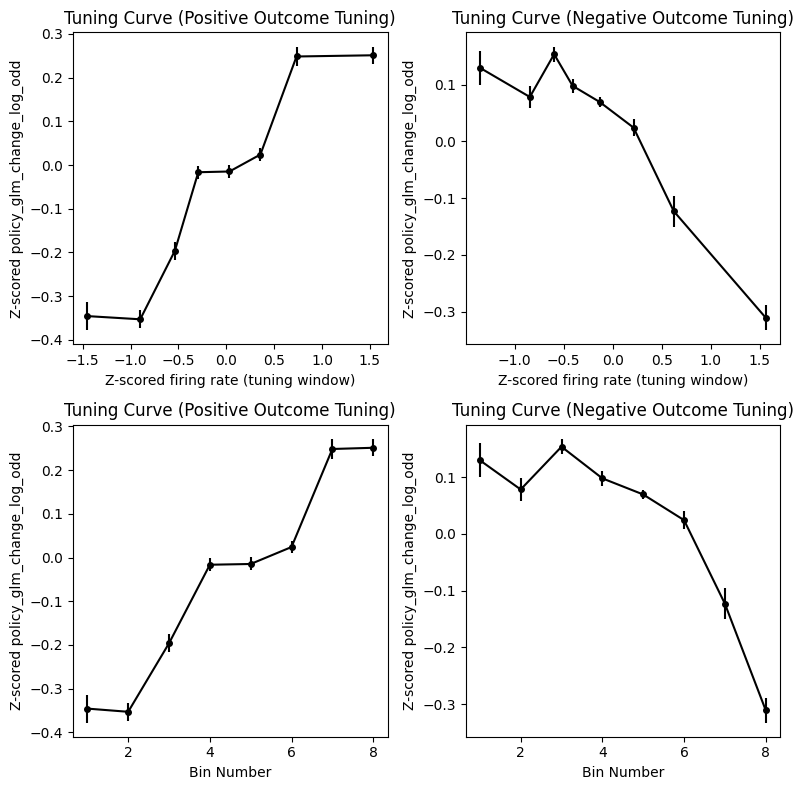

In [70]:
# custom colormap
custom_cmap = LinearSegmentedColormap.from_list(
    'red_white_blue', [(0.0, 'red'), (0.5, 'white'), (1.0, 'blue')]
)
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# plot tuning curves positive
ax = axes[0, 0]
ax.errorbar(
    neuron_means_combined_P,
    np.nanmean(target_means_P, axis=0),
    yerr=np.nanstd(target_means_P, axis=0)/np.sqrt(len(target_means_P)),
    fmt='-o',
    color='k',
    markersize=4,
)
ax.set_title('Tuning Curve (Positive Outcome Tuning)')
ax.set_ylabel(f'Z-scored {target_var}')
ax.set_xlabel('Z-scored firing rate (tuning window)')
# plot tuning curves negative
ax = axes[0, 1]
ax.errorbar(
    neuron_means_combined_N,
    np.nanmean(target_means_N, axis=0),
    yerr=np.nanstd(target_means_N, axis=0)/np.sqrt(len(target_means_N)),
    fmt='-o',
    color='k',
    markersize=4,

)

ax.set_title('Tuning Curve (Negative Outcome Tuning)')
ax.set_ylabel(f'Z-scored {target_var}')
ax.set_xlabel('Z-scored firing rate (tuning window)')

# anoter version of using bin number as x-axis
ax = axes[1, 0]
ax.errorbar(
    np.arange(1, num_bins + 1),
    np.nanmean(target_means_P, axis=0),
    yerr=np.nanstd(target_means_P, axis=0)/np.sqrt(len(target_means_P)),
    fmt='-o',
    color='k',
    markersize=4,

)
ax.set_title('Tuning Curve (Positive Outcome Tuning)')
ax.set_xlabel('Bin Number')
ax.set_ylabel(f'Z-scored {target_var}')
# anoter version of using bin number as x-axis
ax = axes[1, 1]
ax.errorbar(
    np.arange(1, num_bins + 1),
    np.nanmean(target_means_N, axis=0),
    yerr=np.nanstd(target_means_N, axis=0)/np.sqrt(len(target_means_N)),
    fmt='-o',
    color='k',
    markersize=4,

)

ax.set_title('Tuning Curve (Negative Outcome Tuning)')
ax.set_ylabel(f'Z-scored {target_var}')
ax.set_xlabel('Bin Number')

plt.tight_layout()
save_panels(fig, target_folder, f'Rev_tuning_curves_outcome_{target_var}_{criteria_name}', ['Figure6h'], exts=('pdf',), bbox_inches='tight')

# ---- panel CSV (rule 5 errorbar: tuning curves positive & negative) ----
save_panel_csv(columns_to_df(pos_fr=neuron_means_combined_P, pos_target_mean=np.nanmean(target_means_P, axis=0), pos_target_sem=np.nanstd(target_means_P, axis=0) / np.sqrt(len(target_means_P)), neg_fr=neuron_means_combined_N, neg_target_mean=np.nanmean(target_means_N, axis=0), neg_target_sem=np.nanstd(target_means_N, axis=0) / np.sqrt(len(target_means_N))), target_folder, f'Rev_tuning_curves_outcome_{target_var}_{criteria_name}', ['Figure6h'])

##Figure6h##